In [237]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cupy as cp
from unittest.mock import patch
from sklearn.linear_model import LinearRegression
data_file = 'combined_ensemble_predictions_averaged_with_q.csv'
# Since the data has 3 classes, we want to collapse them into one q-value that maps the progression between healthy and full AD.
# [0, 0.5, 1] is equal weighting, where a patient uniformly progresses between CN and reaches AD.
# These values can be changed based on research and existing profiles of AD patients to be more realistic when modelling q.
constant_q_weighting = np.array([0, 0.5, 1])
constant_dx_to_q = {0: constant_q_weighting[0], 1: constant_q_weighting[1], 2: constant_q_weighting[2]}

def direct_q():
    dataframe = pd.read_csv('combined_ensemble_predictions_averaged.csv')
    dataframe['pred_q'] = (constant_q_weighting[0] * dataframe['CNPred']) + (constant_q_weighting[1] * dataframe['MCIPred']) + (constant_q_weighting[2] * dataframe['ADPred'])
    dataframe['true_q'] = dataframe['FollowupDX'].map(constant_dx_to_q)
    dataframe.to_csv(data_file, index=False)

In [238]:
df=pd.read_csv('combined_ensemble_predictions_averaged_with_q.csv')
df

,RID,delta_t,CNPred,MCIPred,ADPred,BaselineDX,FollowupDX,pred_q,true_q
0,4.0,12.1639,0.039251,0.622712,0.338037,1,1,0.649393,0.5
1,4.0,36.2623,0.015806,0.482246,0.501948,1,1,0.743071,0.5
2,5.0,11.9016,0.800081,0.199276,0.000642,0,0,0.100280,0.0
3,5.0,23.9344,0.759345,0.240200,0.000455,0,0,0.120555,0.0
4,5.0,36.0328,0.723376,0.276244,0.000380,0,0,0.138502,0.0
...,...,...,...,...,...,...,...,...,...
4708,7088.0,11.8361,0.002461,0.324007,0.673533,1,2,0.835536,1.0
4709,7088.0,24.0000,0.000748,0.259021,0.740231,1,2,0.869741,1.0
4710,7088.0,36.0000,0.000398,0.228977,0.770625,1,2,0.885114,1.0
4711,7088.0,48.0000,0.000228,0.212631,0.787141,1,2,0.893456,1.0


In [239]:
import sys
sys.path.append('/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/')
import optimalrcs,metrics,plots,nonparametrics,cut_profiles


In [240]:
i_traj=cp.asarray(df['RID'].to_numpy(),dtype=np.int32)
print(i_traj.shape)
print(i_traj)

r_traj=cp.asarray(df['pred_q'].to_numpy(),dtype=np.float32)
print(r_traj.shape)
print(r_traj)

(4713,)
[   4    4    5 ... 7088 7088 7088]
(4713,)
[0.6493932  0.7430712  0.10028047 ... 0.8851136  0.89345634 0.8985571 ]


# First we plot free energy profile along some Order Parameter (OP) - 
variable, that can be used to define the boundary states.

we consider first and second halves of the profiles to see the range of statistical fluctiations/uncertainity 

on the right panel we shifted curves of halfs of trajectories for better overlap

/home/staff7/fbsskr/Notebooks/optimalrcs-cupy/plots.py:86: RuntimeWarning: divide by zero encountered in log
  ax.plot(lx[:-2].get(), -np.log(2 * lzh[:-2].get()), lt)
/tmp/ipykernel_2407117/3799135420.py:13: RuntimeWarning: divide by zero encountered in log
  ax2.plot(lx[:-2].get(), -np.log(2 * lzh[:-2].get()),'-r', label='full')
/tmp/ipykernel_2407117/3799135420.py:15: RuntimeWarning: divide by zero encountered in log
  ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'g:', label='1/2')
/tmp/ipykernel_2407117/3799135420.py:17: RuntimeWarning: divide by zero encountered in log
  ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'b:', label='2/2')


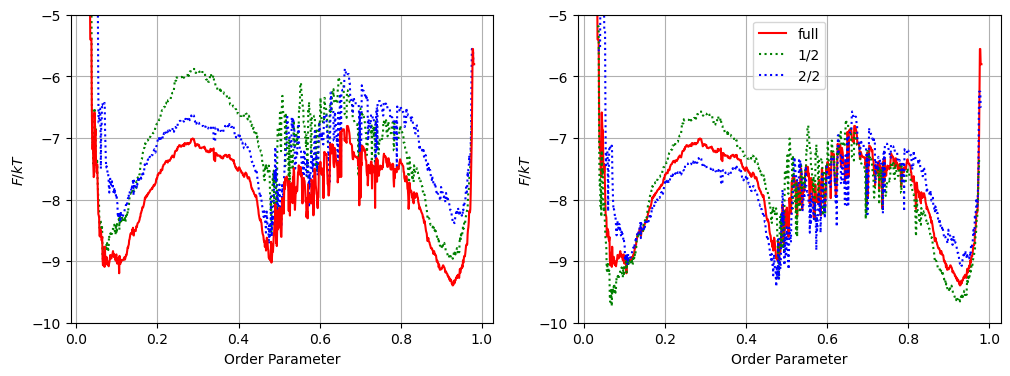

In [241]:
#OP=df['MCIPred'].to_numpy()/2+ df['ADPred'].to_numpy()
OP=r_traj

fig, (ax1,ax2)=plt.subplots(1,2,figsize=(12,4))

nn=len(OP)//2
plots.plot_fep(ax1,OP[:nn],lt='g:', i_traj=cp.asarray(i_traj[:nn]))
plots.plot_fep(ax1,OP[nn:],lt='b:', i_traj=cp.asarray(i_traj[nn:]))
plots.plot_fep(ax1,OP,xlabel='Order Parameter',lt='r-', i_traj=cp.asarray(i_traj))
ax1.set(ylim=(-10,-5))

lx, lzh = cut_profiles.comp_zca(cp.asarray(OP), a=-1,i_traj=cp.asarray(i_traj))
ax2.plot(lx[:-2].get(), -np.log(2 * lzh[:-2].get()),'-r', label='full')
lx, lzh = cut_profiles.comp_zca(cp.asarray(OP[:nn]), a=-1,i_traj=cp.asarray(i_traj[:nn]))
ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'g:', label='1/2')
lx, lzh = cut_profiles.comp_zca(cp.asarray(OP[nn:]), a=-1,i_traj=cp.asarray(i_traj[nn:]))
ax2.plot(lx[:-2].get(), -np.log(4 * lzh[:-2].get()),'b:', label='2/2')
    
ax2.set(ylabel='$F/kT$', xlabel='Order Parameter')
ax2.grid()
ax2.set(ylim=(-10,-5))
_=ax2.legend()


In [242]:
import re

lat_df = pd.read_csv('latent_representations_per_visit.csv')

def parse_latent_string(s: str) -> np.ndarray:
    cleaned = re.sub(r'\s+', ' ', s.strip().strip('[]'))
    return np.fromstring(cleaned, sep=' ')

lat_df['latent_vec'] = lat_df['latent'].apply(parse_latent_string)
df['latent_vec'] = lat_df['latent_vec'].values

z_traj = np.vstack(df['latent_vec'].values)

z_mean = z_traj.mean(axis=0)
z_std  = z_traj.std(axis=0)
z_std[z_std == 0] = 1.0
z_traj = (z_traj - z_mean) / z_std

print(f"z_traj shape: {z_traj.shape}")

z_traj shape: (4713, 32)


In [243]:
z_traj

array([[-0.06218813, -0.69426885, -0.63596854, ..., -0.21198935,
        -0.51346582, -0.89130044],
       [ 0.38380648, -0.80851309, -0.63596854, ...,  0.26556017,
        -0.2333904 , -0.91211003],
       [-0.79987639,  1.42843775,  1.51604249, ..., -1.01141819,
         0.41239149,  1.35753076],
       ...,
       [ 0.93657132, -0.90756277, -0.63596854, ...,  0.95584917,
         0.32336022, -0.9400388 ],
       [ 1.05279809, -0.90756277, -0.63596854, ...,  1.12104561,
         0.42084523, -0.93460546],
       [ 1.14859991, -0.90756277, -0.63596854, ...,  1.26942671,
         0.48212454, -0.93025451]], shape=(4713, 32))

In [244]:
import torch
from dataset import ADNI_tabular
from models.nmm import NMM
from utils.directory_navigator import DirectoryNavigator
N_RT = 20
N_RV = 3
N_RI = 3
root = './'
model_width = 128
model_depth = 3
num_classes = 3
dropout_rate = 0
model_name = 'NMM'
is_multi = True
fixed_followup_year = 0
num_of_tabular_features = 114
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
root_splits = root + 'splits/'
raw_patient_inputs = {}
from utils.directory_navigator import DirectoryNavigator
dir_navi = DirectoryNavigator(root_splits, model_name, is_multi, fixed_followup_year)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='numpy')

def get_baseline_loader(i_rt, i_rv, dir_navi):
    dataset = ADNI_tabular(
        trainvaltest='Test',
        is_multi=is_multi,
        fixed_followup_year=fixed_followup_year,
        data_dir=dir_navi.get_data_dir(i_rt, i_rv=i_rv)
    )
    return torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

raw_patient_features = {}  # stores (114,) features array per RID, patient-level

for i_rt in range(N_RT):
    for i_rv in range(N_RV):
        loader = get_baseline_loader(i_rt, i_rv, dir_navi)
        batch = next(iter(loader))
        rids = [r.item() if hasattr(r, 'item') else r for r in batch['RID']]
        
        raw_input = torch.cat([
            batch['Features'],
            batch['delta_t'].unsqueeze(-1)
        ], dim=1).numpy()


        for idx, rid in enumerate(rids):
            if rid not in raw_patient_features:
                raw_patient_features[rid] = raw_input[idx].copy()

# Merge static features onto the visit-level df, then append each visit's actual delta_t.
# This gives one 115-dim row per visit: 114 clinical features + the real delta_t for that visit.
feat_df = pd.DataFrame({
    'RID': list(raw_patient_features.keys()),
    'features': list(raw_patient_features.values())
})
df_with_raw = df.merge(feat_df, on='RID', how='inner')

F = np.vstack(df_with_raw['features'].values)
delta_t_col = df_with_raw['delta_t'].values.reshape(-1, 1)
X_raw = np.hstack([F, delta_t_col])

X_raw

array([[-8.72343659e-01, -2.19731951e+00, -3.65367606e-02, ...,
         1.00000000e+00,  1.21639000e+01,  1.21639000e+01],
       [-8.72343659e-01, -2.19731951e+00, -3.65367606e-02, ...,
         1.00000000e+00,  1.21639000e+01,  3.62623000e+01],
       [-1.48661761e-02, -3.11584529e-02, -9.85048354e-01, ...,
         1.00000000e+00,  1.19016000e+01,  1.19016000e+01],
       ...,
       [-5.20587742e-01, -2.18316223e-02,  4.66481209e-01, ...,
         1.00000000e+00,  1.18361000e+01,  3.60000000e+01],
       [-5.20587742e-01, -2.18316223e-02,  4.66481209e-01, ...,
         1.00000000e+00,  1.18361000e+01,  4.80000000e+01],
       [-5.20587742e-01, -2.18316223e-02,  4.66481209e-01, ...,
         1.00000000e+00,  1.18361000e+01,  6.00000000e+01]],
      shape=(4713, 65))

In [245]:
df_with_raw['features'][0]

array([-8.72343659e-01, -2.19731951e+00, -3.65367606e-02, -6.24240160e-01,
        0.00000000e+00,  4.99637948e-16,  6.07844554e-16,  1.21457399e-15,
       -5.13621297e-16, -4.06403391e-16,  1.19124236e-15,  0.00000000e+00,
        4.61885001e-16,  5.61126664e-16,  0.00000000e+00,  0.00000000e+00,
       -3.75613743e-16,  5.01164778e-16,  1.08434153e+00,  8.98139775e-01,
        4.08278465e-01, -5.31974614e-01,  2.58193887e-03,  9.16147530e-01,
       -1.01547875e-01, -4.89210635e-01, -7.76520550e-01, -1.91463399e+00,
        2.55426812e+00,  0.00000000e+00, -7.93946862e-01, -1.11093986e+00,
        1.32560313e+00, -1.31776953e+00, -1.26563811e+00,  0.00000000e+00,
        2.44513560e-14,  0.00000000e+00,  5.53597771e-02, -8.66953880e-02,
        1.15528297e+00,  4.80828434e-01,  5.63380659e-01, -6.75845146e-02,
        8.85078013e-01,  1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  

In [246]:
def plot_filtered(q, lag_times):
    q.plots_feps(ldt=lag_times)
    q.plots_obs_pred()

In [257]:
def make_mci_ad_biological_time_seed(
    df,
    cn_col="CNPred",
    mci_col="MCIPred",
    ad_col="ADPred",
    preclinical_months=240.0,
    mci_due_ad_months=60.0,
    reversion_or_stable_prob=0.40,
    ad_floor_months=3.0,
    clip_min=3.0,
    clip_max=360.0,
):
    """
    Build an MFPT-like time-to-AD seed from class probabilities.

    Assumptions encoded:
    - CN/preclinical AD can span 10-30 years; default midpoint = 20 years.
    - MCI due to AD often progresses over ~2-5 years; default = 5 years.
    - ~40% of MCI may remain stable/revert, so MCI is treated as a mixture:
        expected MCI time = 0.6 * MCI_due_AD_time + 0.4 * preclinical/stable time.
    - AD probability contributes near-zero remaining time.
    """

    cn = df[cn_col].to_numpy(dtype=float)
    mci = df[mci_col].to_numpy(dtype=float)
    ad = df[ad_col].to_numpy(dtype=float)

    probs = np.vstack([cn, mci, ad]).T
    probs = np.clip(probs, 0.0, 1.0)
    probs = probs / probs.sum(axis=1, keepdims=True)

    cn = probs[:, 0]
    mci = probs[:, 1]
    ad = probs[:, 2]

    mci_expected_months = (
        (1.0 - reversion_or_stable_prob) * mci_due_ad_months
        + reversion_or_stable_prob * preclinical_months
    )

    seed_r = (
        cn * preclinical_months
        + mci * mci_expected_months
        + ad * ad_floor_months
    )

    seed_r = np.clip(seed_r, clip_min, clip_max)

    return seed_r

seed_r_derived = make_mci_ad_biological_time_seed(df)
seed_r_derived

array([ 92.63229425,  68.95571242, 218.32592779, ...,  32.6323275 ,
        30.48347991,  29.16937184], shape=(4713,))

In [290]:
def mfpt_model(iterations, gamma, print_step, lag_times, seed_count, ny, envelope_size, seed_r):
    results = []
    print('------------------------------')
    print('MFPT USING MODEL PREDICTIONS')
    print('------------------------------')

    metrics.ldt0=lag_times
    
    optimalrcs.envelope_scale = envelope_size
    
    lvar='MCIPred','ADPred'
    def comp_y():
        var=np.random.choice(lvar)
        y=df[var].to_numpy()
        return y

    results = []
    
    for i in range(seed_count):
        q = optimalrcs.MFPTNE(
            boundary0=OP>0.85,
            i_traj=i_traj,
            t_traj=df['delta_t'].to_numpy()#,
            #seed_r=seed_r
        )
        
        q_original = optimalrcs.MFPTNE(
            boundary0=OP>0.85,
            i_traj=i_traj,
            t_traj=df['delta_t'].to_numpy(),
            seed_r=seed_r
        )
        
        seed = np.random.randint(0, 100000)
        np.random.seed(seed)
        
        q.fit_transform(comp_y, gamma=gamma, max_iter=iterations, print_step=print_step, ny=ny)

        results.append({
            'q_original': q_original,
            'q_optimised': q,
            'seed': seed,
        })

        print(f"--- Seed {i} (np.seed={seed}) ---")
        print("PRE-OPTIMISATION:")
        q_original.plots_feps(ldt=lag_times)
        q_original.plots_obs_pred()
        print("POST-OPTIMISATION:")
        q.plots_feps(ldt=lag_times)
        q.plots_obs_pred()

    return results

In [291]:
def mfpt_latent(iterations, gamma, print_step, lag_times, seed_count, ny, envelope_size, seed_r):
    results = []
    print('------------------------------')
    print('MFPT USING LATENT DATA')
    print('------------------------------')
    
    metrics.ldt0=lag_times
    
    optimalrcs.envelope_scale = envelope_size
    
    def comp_y() -> np.ndarray:
        return z_traj[:, np.random.randint(z_traj.shape[1])]
    
    results = []
    
    for i in range(seed_count):
        q = optimalrcs.MFPTNE(
            boundary0=OP>0.85,
            i_traj=i_traj,
            t_traj=df['delta_t'].to_numpy()#,
            #seed_r=seed_r
        )
        
        q_original = optimalrcs.MFPTNE(
            boundary0=OP>0.85,
            i_traj=i_traj,
            t_traj=df['delta_t'].to_numpy(),
            seed_r=seed_r
        )
        
        seed = np.random.randint(0, 100000)
        np.random.seed(seed)
        
        q.fit_transform(comp_y, gamma=gamma, max_iter=iterations, print_step=print_step, ny=ny)

        results.append({
            'q_original': q_original,
            'q_optimised': q,
            'seed': seed,
        })

        print(f"--- Seed {i} (np.seed={seed}) ---")
        print("PRE-OPTIMISATION:")
        q_original.plots_feps(ldt=lag_times)
        q_original.plots_obs_pred()
        print("POST-OPTIMISATION:")
        q.plots_feps(ldt=lag_times)
        q.plots_obs_pred()

    return results

------------------------------
MFPT USING LATENT DATA
------------------------------
#=0, it=-49.8124, sdzt=7537.88, dzt=17157.5, |dx|=0.777554, time=0.0154982
#=500, it=-1921.75, sdzt=530.661, dzt=53.2678, |dx|=74.0234, time=3.76846
#=1000, it=-2398.24, sdzt=565.159, dzt=58.226, |dx|=22.6701, time=7.52331
#=1500, it=-3261.28, sdzt=1469.75, dzt=96.8297, |dx|=43.9202, time=11.2783
#=2000, it=-4355.4, sdzt=1761.97, dzt=114.947, |dx|=50.4124, time=15.0321
#=2500, it=-6095.45, sdzt=2422.89, dzt=161.683, |dx|=87.6984, time=18.7893
#=3000, it=-8013.81, sdzt=1724, dzt=134.032, |dx|=90.2669, time=22.5441
--- Seed 0 (np.seed=9979) ---
PRE-OPTIMISATION:


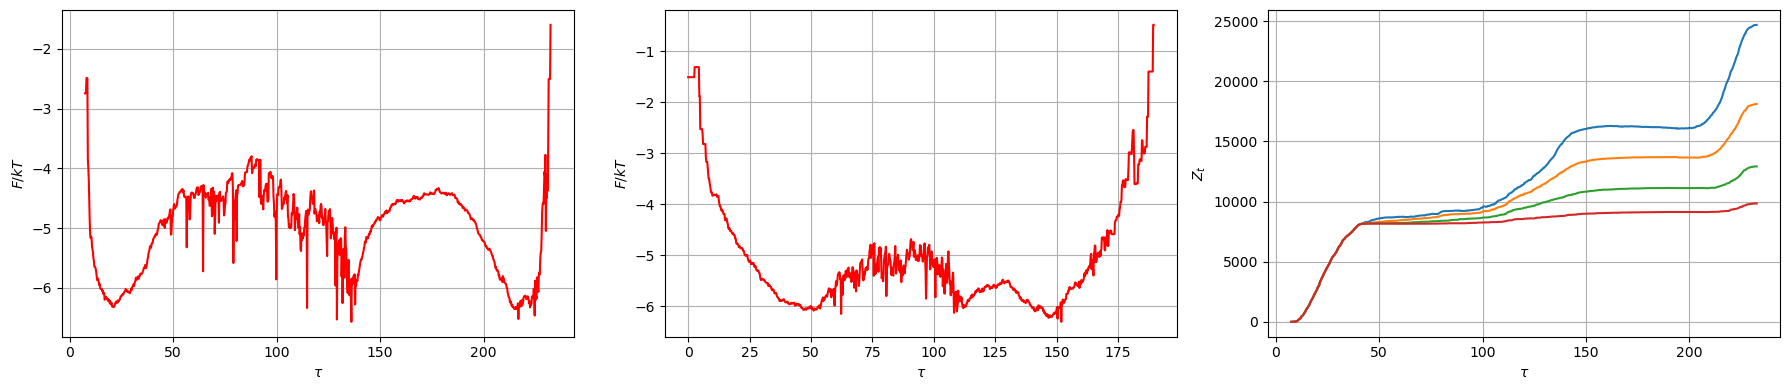

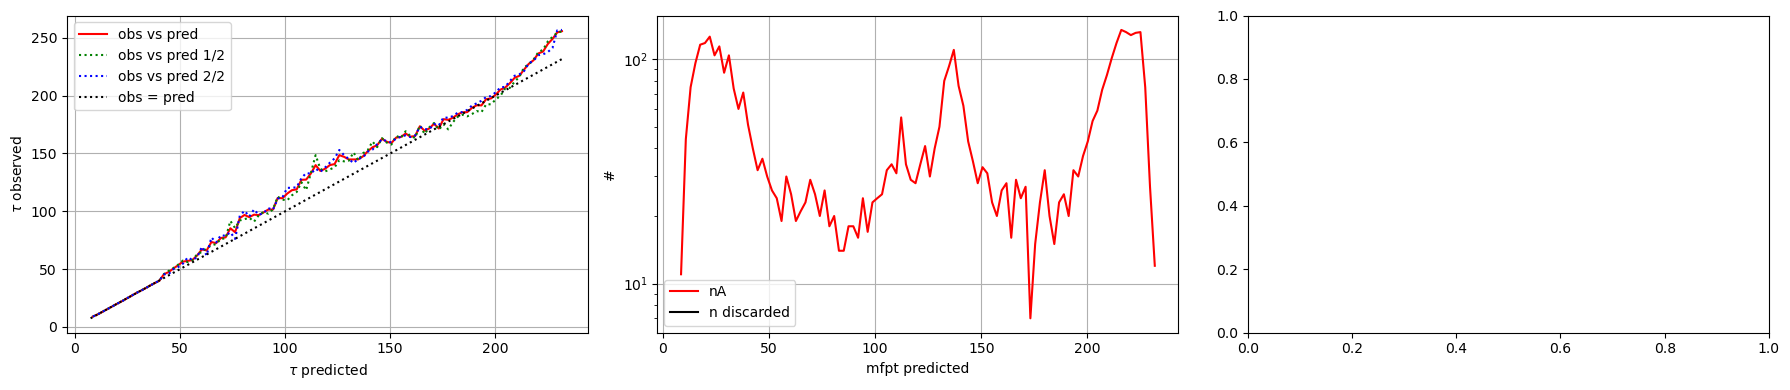

POST-OPTIMISATION:


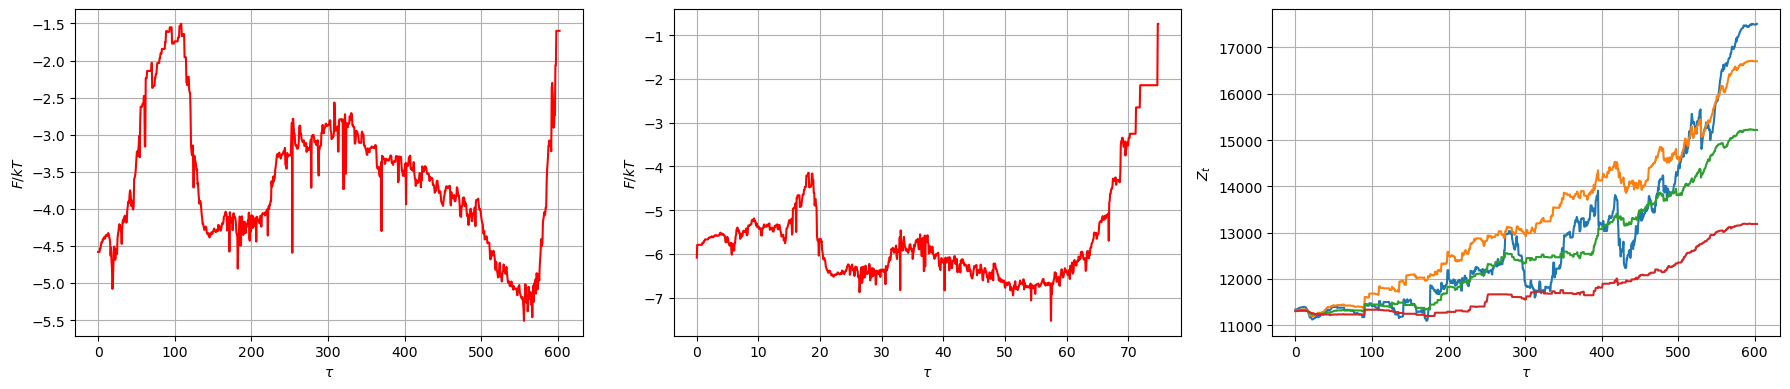

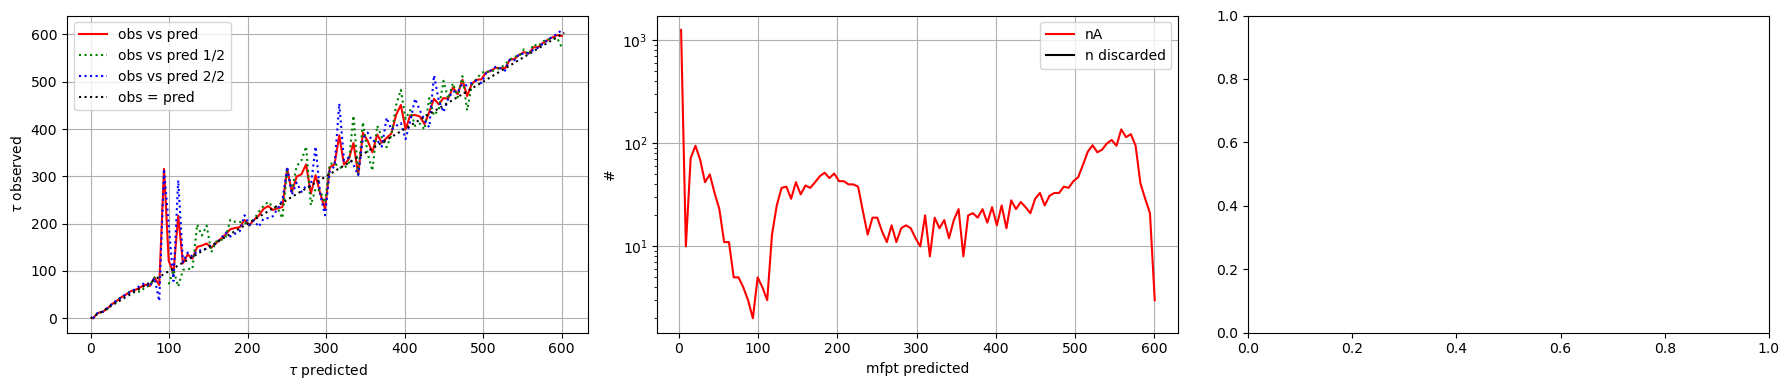

In [293]:
iterations = 3000
gamma = 10
print_step = 500
lag_times = [1, 2, 3, 4]
seed_count = 1
ny = 12
envelope_size = 10

# 97071 9979 good seeds for double peak

#results_model = mfpt_model(iterations, gamma, print_step, lag_times, seed_count, ny, envelope_size, seed_r)
#mfpt_latent(iterations, gamma, print_step, lag_times, seed_count, ny, envelope_size, seed_r)
results_model=mfpt_latent(iterations, gamma, print_step, lag_times, seed_count, ny, envelope_size, seed_r_derived)

# Main Plan

- Premise of the report is about the dual purpose of using optimal RCs, both as an analysis tool to elucidate more information about machine learning models after they have been trained, as well as a potential source of improvement
  
- To begin, I'd talk about the selection of the existing model and dataset and why I chose them, followed by a short part about how I replicated the results of the paper. This would also explain AUC and its potential pitfalls in this application
  
- Next, I'd briefly talk about optimal RCs and how the method works (not too much mathematical detail but I would probably use the LaTeX laid out in your papers if appropriate)
  
- The next section would describe the changes I had to make to the input data to get it working, and I'd justify the use of latent representations as a potential secondary source of optimisation

  
- A short section on the latent representations and how I validated that they did follow a pattern with patient outcome, from when I used clustering, would follow.

  
- The next part would then discuss the reason I chose to use MFPT (one-way progression).


- To begin, an MFPT plot using the model's raw output will be shown. For those that progress to AD, their MFPT will be directly observed (0-60 months), while for MCI patients their MFPT

  
- This would be aided by the Kaplan-Meyer plots you mentioned which I am currently working on making.

  
- The overall aim would be to show that optimalrcs can be used to paint a comprehensive picture of how well a model interprets dynamics, and conclude with an evaluation of the original model chosen.
 

In [260]:
from collections import defaultdict

def compute_km_data(r_traj, i_traj_np, t_traj_np, boundary_mask, n_bins=4):
    """
    Compute Kaplan-Meier survival data stratified by initial RC value.
    
    This is the MFPT adaptation of experimental.plots_SA_q. Instead of
    stratifying by committor probability, we stratify by the MFPT-like
    reaction coordinate at each patient's first observation.
    
    Parameters:
        r_traj:        array, the reaction coordinate value per visit
                       (use q.r_traj for baseline or optimised)
        i_traj_np:     array of patient IDs per visit (df['RID'].to_numpy())
        t_traj_np:     array of observation times per visit (df['delta_t'].to_numpy())
        boundary_mask: boolean array, True where patient reached AD
                       ((df['FollowupDX'] == 2).to_numpy())
        n_bins:        number of RC strata
    
    Returns:
        dict mapping bin labels to lists of (time, survival_probability) tuples
    """
    # Convert cupy arrays if needed
    if hasattr(r_traj, 'get'):
        r_traj = r_traj.get()
    if hasattr(i_traj_np, 'get'):
        i_traj_np = i_traj_np.get()
    
    r_traj = np.asarray(r_traj, dtype=float)
    i_traj_np = np.asarray(i_traj_np)
    t_traj_np = np.asarray(t_traj_np, dtype=float)
    boundary_mask = np.asarray(boundary_mask, dtype=bool)
    
    # --- Step 1: Extract per-patient summary ---
    # For each patient: initial RC value, whether they ever hit AD,
    # and the time at which they did (or their last observation time)
    patient_data = {}
    
    # Walk through visits grouped by patient
    unique_ids = np.unique(i_traj_np)
    for pid in unique_ids:
        mask = i_traj_np == pid
        idx = np.where(mask)[0]
        
        r_first = r_traj[idx[0]]           # RC at first visit
        times = t_traj_np[idx]
        hit_boundary = boundary_mask[idx]
        
        if np.any(hit_boundary):
            # Patient reached AD — event observed
            event_time = times[np.argmax(hit_boundary)]
            censored = False
        else:
            # Patient never reached AD — right-censored at last observation
            event_time = times[-1]
            censored = True
        
        patient_data[pid] = {
            'r_first': r_first,
            'event_time': event_time,
            'censored': censored,
        }
    
    # --- Step 2: Bin patients by initial RC value ---
    r_firsts = np.array([v['r_first'] for v in patient_data.values()])
    bin_edges = np.quantile(r_firsts, np.linspace(0, 1, n_bins + 1))
    bin_edges[0] -= 1e-10   # include the minimum
    bin_edges[-1] += 1e-10  # include the maximum
    
    # --- Step 3: Kaplan-Meier per bin ---
    km_curves = {}
    
    for b in range(n_bins):
        lo, hi = bin_edges[b], bin_edges[b + 1]
        label = f'RC ∈ [{lo:.1f}, {hi:.1f})'
        
        # Collect events and censoring times for this bin
        event_times = []
        censor_times = []
        for v in patient_data.values():
            if lo <= v['r_first'] < hi:
                if v['censored']:
                    censor_times.append(v['event_time'])
                else:
                    event_times.append(v['event_time'])
        
        n_total = len(event_times) + len(censor_times)
        if n_total == 0:
            continue
        
        # Combine all times and sort
        all_times = sorted(set(event_times + censor_times))
        
        # KM estimator: S(t) = product over t_i <= t of (1 - d_i / n_i)
        # where d_i = events at t_i, n_i = at risk just before t_i
        n_at_risk = n_total
        survival = 1.0
        curve = [(0.0, 1.0)]  # survival starts at 1
        
        for t in all_times:
            d = event_times.count(t)       # deaths at this time
            c = censor_times.count(t)      # censorings at this time
            
            if d > 0 and n_at_risk > 0:
                survival *= (1.0 - d / n_at_risk)
            
            curve.append((t, survival))
            n_at_risk -= (d + c)
        
        km_curves[label] = {
            'curve': curve,
            'n_patients': n_total,
            'n_events': len(event_times),
        }
    
    return km_curves

In [261]:
def plot_km_curves(km_curves, title='Kaplan-Meier: Survival (no AD) by RC stratum',
                   xlabel='Follow-up time (months)', ax=None):
    """
    Plot Kaplan-Meier survival curves from compute_km_data output.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(km_curves)))
    
    for (label, data), color in zip(km_curves.items(), colors):
        times, surv = zip(*data['curve'])
        n = data['n_patients']
        ev = data['n_events']
        ax.step(times, surv, where='post', color=color,
                label=f'{label}  (n={n}, events={ev})', linewidth=2)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Survival probability (AD-free)')
    ax.set_title(title)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    
    return ax

In [262]:
def plot_km_comparison(results, df, n_bins=5, seed_selection='best'):
    """
    Side-by-side Kaplan-Meier: baseline vs optimised.
    
    Parameters:
        results:        output of mfpt_model()
        df:             your dataframe
        n_bins:         number of RC strata (try 5 or 6 for finer resolution)
        seed_selection: 'best', 'worst', 'median', or an integer index
    """
    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    
    # --- Select seed by C-index ---
    if isinstance(seed_selection, int):
        chosen_idx = seed_selection
    else:
        # Compute C-index for each seed's optimised RC
        c_indices = []
        for res in results:
            c = concordance_index(res['q_optimised'].r_traj, df)
            c_indices.append(c)
        
        c_indices = np.array(c_indices)
        
        if seed_selection == 'best':
            chosen_idx = int(np.argmax(c_indices))
        elif seed_selection == 'worst':
            chosen_idx = int(np.argmin(c_indices))
        elif seed_selection == 'median':
            # Pick the seed whose C-index is closest to the median
            median_val = np.median(c_indices)
            chosen_idx = int(np.argmin(np.abs(c_indices - median_val)))
        else:
            chosen_idx = 0
        
        print(f"Selected seed {chosen_idx} "
              f"(np.seed={results[chosen_idx]['seed']}, "
              f"C-index={c_indices[chosen_idx]:.4f}, "
              f"selection='{seed_selection}')")
        print(f"C-index range across all seeds: "
              f"{c_indices.min():.4f} – {c_indices.max():.4f}, "
              f"median={np.median(c_indices):.4f}")
    
    res = results[chosen_idx]
    
    # --- Compute KM for baseline and optimised ---
    km_base = compute_km_data(res['q_original'].r_traj, i_traj_np,
                              t_traj_np, boundary, n_bins=n_bins)
    km_opt = compute_km_data(res['q_optimised'].r_traj, i_traj_np,
                             t_traj_np, boundary, n_bins=n_bins)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    
    plot_km_curves(km_base,
                   title=f'Baseline (ML model seed_r, {n_bins} strata)',
                   ax=ax1)
    plot_km_curves(km_opt,
                   title=(f'Optimised (seed={res["seed"]}, '
                          f'{seed_selection}, {n_bins} strata)'),
                   ax=ax2)
    
    plt.tight_layout()
    plt.show()

In [263]:
def plot_km_overlay_seeds(results, df, n_bins=4, which='optimised'):
    """
    Overlay KM curves from multiple seeds to check consistency.
    
    Parameters:
        which: 'optimised' or 'baseline'
    """
    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    
    fig, axes = plt.subplots(1, n_bins, figsize=(5 * n_bins, 5), sharey=True)
    if n_bins == 1:
        axes = [axes]
    
    # Collect all curves per bin across seeds
    all_km = []
    for res in results:
        key = 'q_optimised' if which == 'optimised' else 'q_original'
        r = res[key].r_traj
        km = compute_km_data(r, i_traj_np, t_traj_np, boundary, n_bins=n_bins)
        all_km.append(km)
    
    # For each bin, overlay all seeds
    bin_labels = list(all_km[0].keys())
    for b, label in enumerate(bin_labels):
        ax = axes[b]
        for s, km in enumerate(all_km):
            if label in km:
                times, surv = zip(*km[label]['curve'])
                ax.step(times, surv, where='post', alpha=0.4,
                        label=f'seed {s}')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Months')
        if b == 0:
            ax.set_ylabel('Survival')
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'KM consistency across {len(results)} seeds ({which})')
    plt.tight_layout()
    plt.show()

In [264]:
def plot_tpt_distribution(r_traj, df, n_bins=4, time_scale=1):
    """
    Distribution of actual transition times to AD, stratified by initial RC.
    This is the MFPT analogue of experimental.plots_tpt_q.
    
    Parameters:
        r_traj: reaction coordinate values per visit
        df: your dataframe
        n_bins: number of strata
        time_scale: divide times by this (1 for months, 12 for years)
    """
    if hasattr(r_traj, 'get'):
        r_traj = r_traj.get()
    r_traj = np.asarray(r_traj, dtype=float)
    
    i_traj_np = df['RID'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    t_traj_np = df['delta_t'].to_numpy().astype(float)
    
    # Collect first-visit RC and time-to-AD for converters
    converters = {}
    unique_ids = np.unique(i_traj_np)
    for pid in unique_ids:
        idx = np.where(i_traj_np == pid)[0]
        if np.any(boundary[idx]):
            r_first = r_traj[idx[0]]
            t_event = t_traj_np[idx][np.argmax(boundary[idx])]
            converters[pid] = (r_first, t_event / time_scale)
    
    if not converters:
        print("No converters found.")
        return
    
    r_firsts = np.array([v[0] for v in converters.values()])
    t_events = np.array([v[1] for v in converters.values()])
    
    bin_edges = np.quantile(r_firsts, np.linspace(0, 1, n_bins + 1))
    bin_edges[0] -= 1e-10
    bin_edges[-1] += 1e-10
    
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, n_bins))
    
    for b in range(n_bins):
        mask = (r_firsts >= bin_edges[b]) & (r_firsts < bin_edges[b + 1])
        if mask.sum() == 0:
            continue
        t_bin = t_events[mask]
        label = f'RC ∈ [{bin_edges[b]:.1f}, {bin_edges[b+1]:.1f}) n={mask.sum()}'
        ax.hist(t_bin, bins=15, alpha=0.5, color=colors[b], label=label, density=True)
    
    unit = 'years' if time_scale == 12 else 'months'
    ax.set_xlabel(f'Time to AD ({unit})')
    ax.set_ylabel('Density')
    ax.set_title('Transition time distribution by initial RC stratum')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.show()

In [265]:
def plot_rc_first_by_outcome(r_traj, df, log_scale=False):
    """
    Histogram of first-visit RC values, split by whether the patient
    eventually reached AD. 
    
    A good RC should show clear separation between the two groups.
    Compare baseline vs optimised to see if separation improves.
    """
    if hasattr(r_traj, 'get'):
        r_traj = r_traj.get()
    r_traj = np.asarray(r_traj, dtype=float)
    
    i_traj_np = df['RID'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    
    unique_ids = np.unique(i_traj_np)
    r_first_converters = []
    r_first_nonconverters = []
    
    for pid in unique_ids:
        idx = np.where(i_traj_np == pid)[0]
        r_first = r_traj[idx[0]]
        if log_scale and r_first > 0:
            r_first = np.log(r_first)
        elif log_scale:
            r_first = np.nan
        
        if np.any(boundary[idx]):
            r_first_converters.append(r_first)
        else:
            r_first_nonconverters.append(r_first)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    bins = np.linspace(
        np.nanmin(r_first_converters + r_first_nonconverters),
        np.nanmax(r_first_converters + r_first_nonconverters),
        30
    )
    
    ax.hist(r_first_nonconverters, bins=bins, alpha=0.6, label=f'No AD (n={len(r_first_nonconverters)})',
            density=True, color='steelblue')
    ax.hist(r_first_converters, bins=bins, alpha=0.6, label=f'AD converters (n={len(r_first_converters)})',
            density=True, color='tomato')
    
    xlabel = 'log(RC) at first visit' if log_scale else 'RC at first visit'
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title('Initial RC distribution by outcome')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_rc_first_comparison(results, df):
    """
    Compare initial RC distribution baseline vs optimised, side by side.
    """
    res = results[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Baseline
    r_base = res['q_original'].r_traj
    if hasattr(r_base, 'get'):
        r_base = r_base.get()
    
    r_opt = res['q_optimised'].r_traj
    if hasattr(r_opt, 'get'):
        r_opt = r_opt.get()
    
    i_traj_np = df['RID'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    
    for r_traj, ax, title in [(r_base, ax1, 'Baseline'),
                               (r_opt, ax2, 'Optimised')]:
        unique_ids = np.unique(i_traj_np)
        rc_conv, rc_nonconv = [], []
        for pid in unique_ids:
            idx = np.where(i_traj_np == pid)[0]
            r_first = r_traj[idx[0]]
            if np.any(boundary[idx]):
                rc_conv.append(r_first)
            else:
                rc_nonconv.append(r_first)
        
        bins = np.linspace(
            min(min(rc_conv, default=0), min(rc_nonconv, default=0)),
            max(max(rc_conv, default=1), max(rc_nonconv, default=1)),
            30
        )
        ax.hist(rc_nonconv, bins=bins, alpha=0.6, density=True,
                label=f'No AD (n={len(rc_nonconv)})', color='steelblue')
        ax.hist(rc_conv, bins=bins, alpha=0.6, density=True,
                label=f'AD (n={len(rc_conv)})', color='tomato')
        ax.set_title(title)
        ax.set_xlabel('RC at first visit')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [266]:
def log_rank_test(km_curves):
    """
    Compute pairwise log-rank test statistics between KM strata.
    Returns a DataFrame of chi-squared statistics and p-values.
    
    A higher chi-squared / lower p-value means better separation,
    i.e., the RC is doing a better job of stratifying risk.
    """
    from scipy.stats import chi2
    
    labels = list(km_curves.keys())
    results = []
    
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            # Extract event and censoring info from the KM data
            # This is a simplified log-rank using the KM curves directly
            c1 = km_curves[labels[i]]
            c2 = km_curves[labels[j]]
            
            n1 = c1['n_patients']
            n2 = c2['n_patients']
            e1 = c1['n_events']
            e2 = c2['n_events']
            
            # Expected events under null (proportional to group size)
            total_n = n1 + n2
            total_e = e1 + e2
            if total_n == 0 or total_e == 0:
                continue
            
            E1 = total_e * n1 / total_n
            E2 = total_e * n2 / total_n
            
            # Chi-squared statistic
            chi2_stat = ((e1 - E1) ** 2 / E1) + ((e2 - E2) ** 2 / E2)
            p_val = 1 - chi2.cdf(chi2_stat, df=1)
            
            results.append({
                'group_1': labels[i],
                'group_2': labels[j],
                'chi2': chi2_stat,
                'p_value': p_val,
            })
    
    return pd.DataFrame(results)

def compare_log_rank(res, df, n_bins=4):
    """
    Compare log-rank statistics before and after optimisation.
    Higher total chi-squared means better risk stratification.
    """
    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    
    km_base = compute_km_data(res['q_original'].r_traj, i_traj_np,
                              t_traj_np, boundary, n_bins=n_bins)
    km_opt = compute_km_data(res['q_optimised'].r_traj, i_traj_np,
                             t_traj_np, boundary, n_bins=n_bins)
    
    lr_base = log_rank_test(km_base)
    lr_opt = log_rank_test(km_opt)
    
    print("=== BASELINE LOG-RANK ===")
    print(lr_base.to_string(index=False))
    print(f"Total chi2: {lr_base['chi2'].sum():.2f}")
    print()
    print("=== OPTIMISED LOG-RANK ===")
    print(lr_opt.to_string(index=False))
    print(f"Total chi2: {lr_opt['chi2'].sum():.2f}")
    
    return lr_base, lr_opt

In [267]:
def plot_patient_trajectories(r_traj, df, n_patients=10, seed=42,
                              trajectory_type='converters'):
    """
    Plot individual patient trajectories on the reaction coordinate,
    focusing on patients who show disease progression.
    
    Parameters:
        r_traj:          RC values per visit
        df:              your dataframe
        n_patients:      how many to plot
        seed:            for reproducible patient selection
        trajectory_type: 'converters'  — patients whose FollowupDX changes
                                         at any point (CN→MCI, MCI→AD, CN→AD)
                         'ad_converters' — only those who reach AD (FollowupDX==2)
                         'all'          — any patient
    """
    if hasattr(r_traj, 'get'):
        r_traj = r_traj.get()
    r_traj = np.asarray(r_traj, dtype=float)

    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy().astype(float)
    dx_traj = df['FollowupDX'].to_numpy()

    # --- Build per-patient summaries to identify interesting trajectories ---
    unique_ids = np.unique(i_traj_np)
    candidates = []

    for pid in unique_ids:
        idx = np.where(i_traj_np == pid)[0]

        # Skip patients with only one visit — no trajectory to show
        if len(idx) < 2:
            continue

        dx_sequence = dx_traj[idx]
        dx_changes = np.sum(np.diff(dx_sequence) != 0)

        if trajectory_type == 'converters':
            # Patient must show at least one change in diagnosis
            # This captures CN→MCI, MCI→AD, or CN→AD transitions
            if dx_changes > 0:
                # Score by number of transitions — more transitions = 
                # more interesting trajectory to visualise
                candidates.append((pid, dx_changes))

        elif trajectory_type == 'ad_converters':
            # Must reach AD at some point
            if np.any(dx_sequence == 2) and dx_sequence[0] < 2:
                candidates.append((pid, dx_changes))

        else:  # 'all'
            candidates.append((pid, dx_changes))

    if not candidates:
        print(f"No patients found matching trajectory_type='{trajectory_type}'")
        return

    # Sort by number of dx transitions (descending) so the most 
    # dynamic trajectories are at the top of the pool, then sample
    # from the top portion to get interesting ones
    candidates.sort(key=lambda x: -x[1])
    
    # Take from the top half of most-dynamic patients to ensure
    # we get visually interesting trajectories, but still randomise
    # within that pool so we don't always show the same patients
    pool_size = max(n_patients * 2, len(candidates) // 2)
    pool = [c[0] for c in candidates[:pool_size]]

    rng = np.random.RandomState(seed)
    chosen = rng.choice(pool, size=min(n_patients, len(pool)), replace=False)

    # --- Diagnosis labels for colouring ---
    dx_labels = {0: 'CN', 1: 'MCI', 2: 'AD'}
    dx_colors = {0: 'forestgreen', 1: 'orange', 2: 'tomato'}

    fig, ax = plt.subplots(figsize=(12, 6))

    for pid in chosen:
        idx = np.where(i_traj_np == pid)[0]
        times = t_traj_np[idx]
        rc_vals = r_traj[idx]
        dx_vals = dx_traj[idx]

        # Draw the trajectory line in grey to connect points
        ax.plot(times, rc_vals, '-', color='grey', alpha=0.3, linewidth=1)

        # Colour each point by its diagnosis at that visit
        for t, r, dx in zip(times, rc_vals, dx_vals):
            ax.scatter(t, r, color=dx_colors[dx], s=30, zorder=3,
                       edgecolors='white', linewidths=0.3)

    # Legend showing what each colour means
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='forestgreen',
               markersize=8, label='CN'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
               markersize=8, label='MCI'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
               markersize=8, label='AD'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_xlabel('Follow-up time (months)')
    ax.set_ylabel('Reaction coordinate (MFPT)')
    ax.set_title(f'Patient trajectories — {trajectory_type} (n={len(chosen)})')
    ax.grid(True, alpha=0.3)
    plt.show()

In [268]:
def concordance_index(r_traj, df):
    """
    Compute Harrell's concordance index for the RC as a time-to-event predictor.
    
    For MFPT: higher RC should mean longer time to AD.
    C-index > 0.5 means the RC is better than random.
    Compare baseline vs optimised to see if discrimination improves.
    """
    if hasattr(r_traj, 'get'):
        r_traj = r_traj.get()
    r_traj = np.asarray(r_traj, dtype=float)
    
    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy().astype(float)
    boundary = (df['FollowupDX'] == 2).to_numpy()
    
    # Per-patient: first-visit RC, event time, censoring
    patients = []
    for pid in np.unique(i_traj_np):
        idx = np.where(i_traj_np == pid)[0]
        r_first = r_traj[idx[0]]
        
        if np.any(boundary[idx]):
            t_event = t_traj_np[idx][np.argmax(boundary[idx])]
            event = True
        else:
            t_event = t_traj_np[idx[-1]]
            event = False
        
        patients.append((r_first, t_event, event))
    
    # Count concordant, discordant, tied pairs
    concordant = 0
    discordant = 0
    tied = 0
    comparable = 0
    
    for i in range(len(patients)):
        for j in range(i + 1, len(patients)):
            ri, ti, ei = patients[i]
            rj, tj, ej = patients[j]
            
            # Only comparable if at least one had an event
            # and the event time is shorter
            if ei and (tj > ti or ej):
                comparable += 1
                if ri < rj:   # lower MFPT RC → faster to AD → shorter time
                    if ti < tj:
                        concordant += 1
                    elif ti > tj:
                        discordant += 1
                    else:
                        tied += 1
                elif ri > rj:
                    if ti > tj:
                        concordant += 1
                    elif ti < tj:
                        discordant += 1
                    else:
                        tied += 1
                else:
                    tied += 1
    
    if concordant + discordant + tied == 0:
        return np.nan
    
    c_index = (concordant + 0.5 * tied) / (concordant + discordant + tied)
    return c_index

def compare_concordance(results, df):
    """
    Compare concordance index before and after optimisation.
    """
    for i, res in enumerate(results):
        c_base = concordance_index(res['q_original'].r_traj, df)
        c_opt = concordance_index(res['q_optimised'].r_traj, df)
        print(f"Seed {i} (np.seed={res['seed']}): "
              f"C-index baseline={c_base:.4f}, optimised={c_opt:.4f}, "
              f"delta={c_opt - c_base:+.4f}")

In [269]:
def plot_late_onset_trajectories(r_traj, df, mfpt_lower=60, mfpt_upper=240,
                                  n_patients=10, seed=42):
    """
    Find and plot patients who:
      - Have an initial MFPT between mfpt_lower and mfpt_upper
      - Are predominantly CN across their trajectory
      - Develop MCI or AD near the end of their observation window
    
    The bounds let you target a specific regime:
      - [60, 240]:  "medium-safe" patients — model thinks they're beyond 
                     the 60-month clinical window but not infinitely far
      - [120, 240]: deeper into the extrapolation regime
      - [40, 80]:   borderline patients near the observation edge
    """
    if hasattr(r_traj, 'get'):
        r_traj = r_traj.get()
    r_traj = np.asarray(r_traj, dtype=float)

    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy().astype(float)
    dx_traj = df['FollowupDX'].to_numpy()

    unique_ids = np.unique(i_traj_np)
    candidates = []

    for pid in unique_ids:
        idx = np.where(i_traj_np == pid)[0]

        if len(idx) < 3:
            continue

        rc_vals = r_traj[idx]
        dx_vals = dx_traj[idx]
        times = t_traj_np[idx]

        # 1. Initial MFPT within the specified band
        if rc_vals[0] < mfpt_lower or rc_vals[0] > mfpt_upper:
            continue

        # 2. Predominantly CN
        cn_fraction = np.mean(dx_vals == 0)
        if cn_fraction < 0.5:
            continue

        # 3. Starts CN, ends with decline
        if dx_vals[0] != 0:
            continue
        if dx_vals[-1] == 0:
            continue

        n_cn = np.sum(dx_vals == 0)
        score = n_cn / len(dx_vals)
        rc_slope = np.polyfit(times, rc_vals, 1)[0] if len(times) > 1 else 0

        candidates.append({
            'pid': pid,
            'idx': idx,
            'score': score,
            'rc_slope': rc_slope,
            'n_visits': len(idx),
            'cn_fraction': cn_fraction,
            'first_rc': rc_vals[0],
            'last_dx': dx_vals[-1],
        })

    if not candidates:
        print(f"No patients found with MFPT ∈ [{mfpt_lower}, {mfpt_upper}] "
              f"who were mostly CN then declined.")
        print("Try widening the MFPT range.")
        return

    candidates.sort(key=lambda x: -x['score'])

    rng = np.random.RandomState(seed)
    n_show = min(n_patients, len(candidates))
    pool = candidates[:max(n_show * 2, len(candidates))]
    chosen = [pool[i] for i in rng.choice(len(pool), size=n_show, replace=False)]

    print(f"Found {len(candidates)} patients matching criteria "
          f"(MFPT ∈ [{mfpt_lower}, {mfpt_upper}], mostly CN, late decline)")
    print(f"Showing {n_show} of them:\n")

    dx_labels = {0: 'CN', 1: 'MCI', 2: 'AD'}
    dx_colors = {0: 'forestgreen', 1: 'orange', 2: 'tomato'}

    fig, ax = plt.subplots(figsize=(14, 7))

    for c in chosen:
        pid = c['pid']
        idx = c['idx']
        times = t_traj_np[idx]
        rc_vals = r_traj[idx]
        dx_vals = dx_traj[idx]

        dx_str = ' → '.join([dx_labels[d] for d in dx_vals])
        print(f"  RID {pid:>6.0f}: RC₀={c['first_rc']:>7.1f}, "
              f"{c['n_visits']} visits, "
              f"slope={c['rc_slope']:+.2f}/month, "
              f"path: {dx_str}")

        ax.plot(times, rc_vals, '-', color='grey', alpha=0.4, linewidth=1.2)

        for t, r, dx in zip(times, rc_vals, dx_vals):
            ax.scatter(t, r, color=dx_colors[dx], s=50, zorder=3,
                       edgecolors='white', linewidths=0.5)

        ax.annotate(f'{int(pid)}', xy=(times[0], rc_vals[0]),
                    fontsize=6, alpha=0.6, ha='right',
                    xytext=(-5, 3), textcoords='offset points')

    # Shade the MFPT band to show the selection region
    ax.axhspan(mfpt_lower, mfpt_upper, alpha=0.07, color='blue',
               label=f'Selection band [{mfpt_lower}, {mfpt_upper}]')

    # Reference line at 60 months (clinical observation limit)
    ax.axhline(y=60, color='red', linestyle='--', alpha=0.4,
               label='MFPT = 60 (observation window)')

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='forestgreen',
               markersize=8, label='CN'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='orange',
               markersize=8, label='MCI'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
               markersize=8, label='AD'),
        Line2D([0], [0], color='red', linestyle='--', alpha=0.4,
               label='MFPT = 60'),
        plt.Rectangle((0, 0), 1, 1, fc='blue', alpha=0.07,
                       label=f'Selection band [{mfpt_lower}, {mfpt_upper}]'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    ax.set_xlabel('Follow-up time (months)')
    ax.set_ylabel('Reaction coordinate (MFPT)')
    ax.set_title(f'Late-onset decline: CN patients with MFPT '
                 f'∈ [{mfpt_lower}, {mfpt_upper}] who develop MCI/AD')
    ax.grid(True, alpha=0.3)
    plt.show()

    slopes = [c['rc_slope'] for c in chosen]
    print(f"\nRC slope statistics (negative = RC decreasing toward AD):")
    print(f"  Mean: {np.mean(slopes):+.3f}/month")
    print(f"  Patients with negative slope: "
          f"{sum(1 for s in slopes if s < 0)}/{len(slopes)}")

In [270]:
def select_best_seed(results, df, criterion='best', verbose=True):
    """
    Evaluate all seeds by concordance index and return the chosen index.
    
    Call this once after mfpt_model() finishes, then use the returned
    index everywhere else.
    
    Parameters:
        results:   output of mfpt_model()
        df:        your dataframe
        criterion: 'best', 'worst', or 'median'
        verbose:   if True, print summary statistics
    
    Returns:
        chosen_idx: integer index into results list
    """
    c_indices = np.array([
        concordance_index(res['q_optimised'].r_traj, df)
        for res in results
    ])
    
    if criterion == 'best':
        chosen_idx = int(np.argmax(c_indices))
    elif criterion == 'worst':
        chosen_idx = int(np.argmin(c_indices))
    elif criterion == 'median':
        chosen_idx = int(np.argmin(np.abs(c_indices - np.median(c_indices))))
    else:
        raise ValueError(f"Unknown criterion: {criterion}")
    
    if verbose:
        baseline_c = concordance_index(results[0]['q_original'].r_traj, df)
        print(f"Baseline C-index: {baseline_c:.4f}")
        print(f"Optimised C-index across {len(results)} seeds:")
        print(f"  Min:    {c_indices.min():.4f}  (seed idx {np.argmin(c_indices)}, "
              f"np.seed={results[int(np.argmin(c_indices))]['seed']})")
        print(f"  Median: {np.median(c_indices):.4f}")
        print(f"  Max:    {c_indices.max():.4f}  (seed idx {np.argmax(c_indices)}, "
              f"np.seed={results[int(np.argmax(c_indices))]['seed']})")
        print(f"  Mean improvement: +{(c_indices.mean() - baseline_c):.4f}")
        print(f"")
        print(f"Selected: idx={chosen_idx}, "
              f"np.seed={results[chosen_idx]['seed']}, "
              f"C-index={c_indices[chosen_idx]:.4f} ({criterion})")
    
    return chosen_idx

In [271]:
def plot_best_seed_feps(results, best_idx, lag_times):
    """
    Plot the standard optimalrcs diagnostics (FEPs + obs vs pred)
    for the selected best seed, showing baseline and optimised side by side.
    
    Parameters:
        results:   output of mfpt_model()
        best_idx:  index from select_best_seed()
        lag_times: same lag_times used in optimisation
    """
    res = results[best_idx]
    print(f"Showing FEPs for seed idx={best_idx}, "
          f"np.seed={res['seed']}")

    print("\n--- BASELINE (ML model seed_r) ---")
    res['q_original'].plots_feps(ldt=lag_times)
    res['q_original'].plots_obs_pred()

    print("\n--- OPTIMISED ---")
    res['q_optimised'].plots_feps(ldt=lag_times)
    res['q_optimised'].plots_obs_pred()

Baseline C-index: 0.8927
Optimised C-index across 1 seeds:
  Min:    0.8618  (seed idx 0, np.seed=97071)
  Median: 0.8618
  Max:    0.8618  (seed idx 0, np.seed=97071)
  Mean improvement: +-0.0309

Selected: idx=0, np.seed=97071, C-index=0.8618 (best)
Selected seed 0 (np.seed=97071, C-index=0.8618, selection='best')
C-index range across all seeds: 0.8618 – 0.8618, median=0.8618


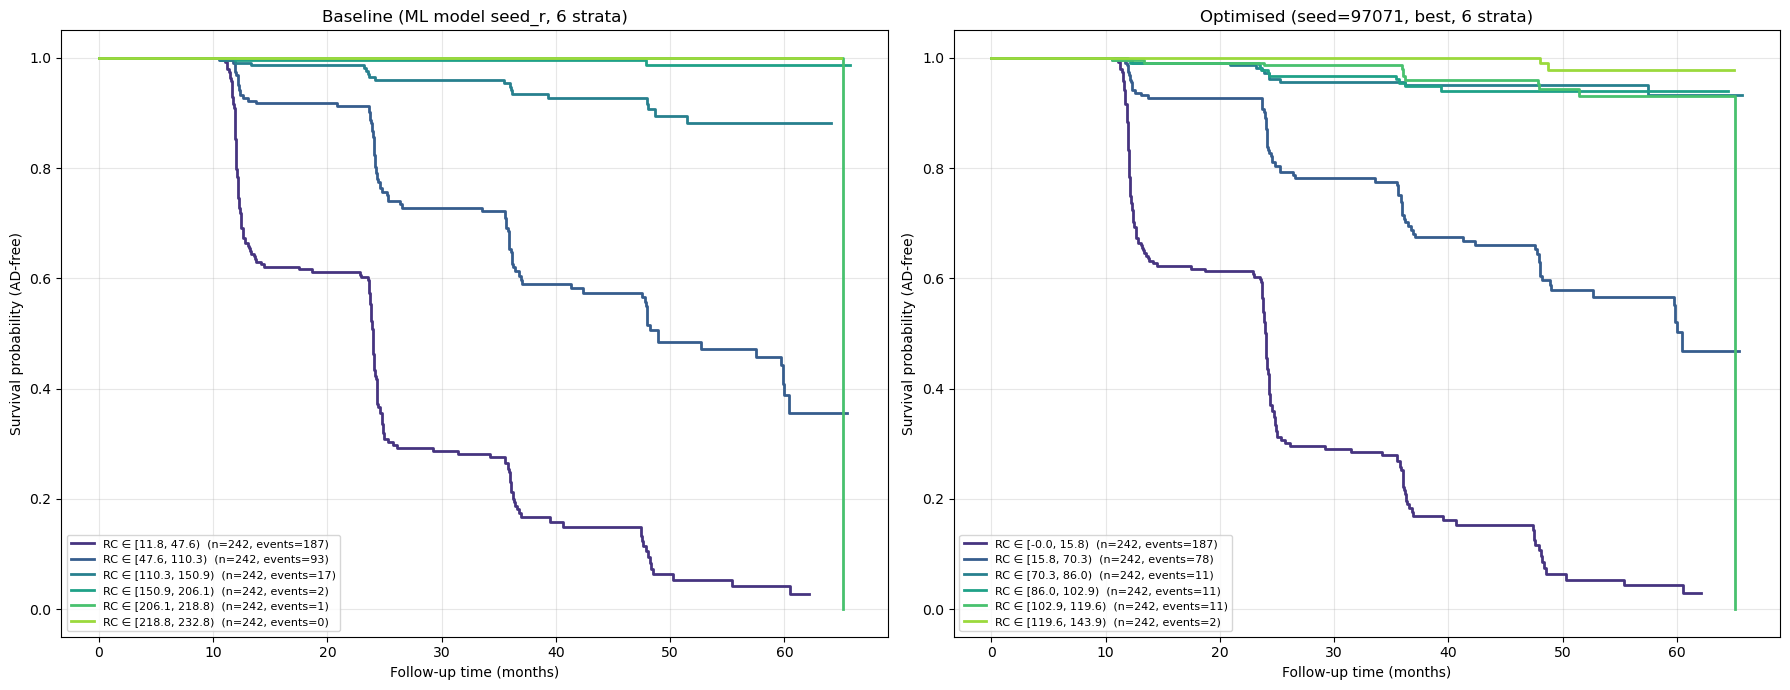

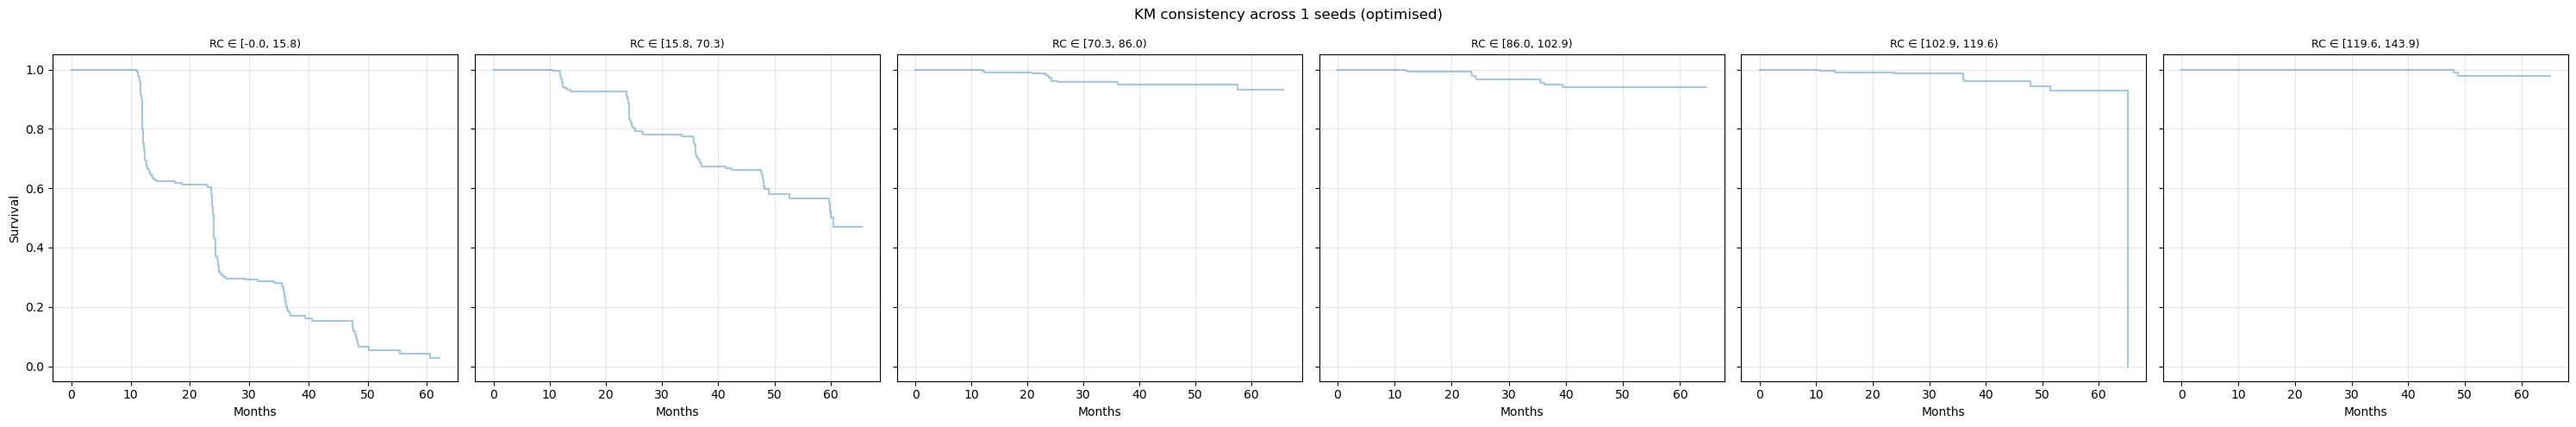

=== BASELINE LOG-RANK ===
            group_1             group_2       chi2      p_value
  RC ∈ [11.8, 47.6)  RC ∈ [47.6, 110.3)  31.557143 1.936567e-08
  RC ∈ [11.8, 47.6) RC ∈ [110.3, 150.9) 141.666667 0.000000e+00
  RC ∈ [11.8, 47.6) RC ∈ [150.9, 206.1) 181.084656 0.000000e+00
  RC ∈ [11.8, 47.6) RC ∈ [206.1, 218.8) 184.021277 0.000000e+00
  RC ∈ [11.8, 47.6) RC ∈ [218.8, 232.8) 187.000000 0.000000e+00
 RC ∈ [47.6, 110.3) RC ∈ [110.3, 150.9)  52.509091 4.282130e-13
 RC ∈ [47.6, 110.3) RC ∈ [150.9, 206.1)  87.168421 0.000000e+00
 RC ∈ [47.6, 110.3) RC ∈ [206.1, 218.8)  90.042553 0.000000e+00
 RC ∈ [47.6, 110.3) RC ∈ [218.8, 232.8)  93.000000 0.000000e+00
RC ∈ [110.3, 150.9) RC ∈ [150.9, 206.1)  11.842105 5.790632e-04
RC ∈ [110.3, 150.9) RC ∈ [206.1, 218.8)  14.222222 1.624408e-04
RC ∈ [110.3, 150.9) RC ∈ [218.8, 232.8)  17.000000 3.737982e-05
RC ∈ [150.9, 206.1) RC ∈ [206.1, 218.8)   0.333333 5.637029e-01
RC ∈ [150.9, 206.1) RC ∈ [218.8, 232.8)   2.000000 1.572992e-01
RC ∈ [206.1, 2

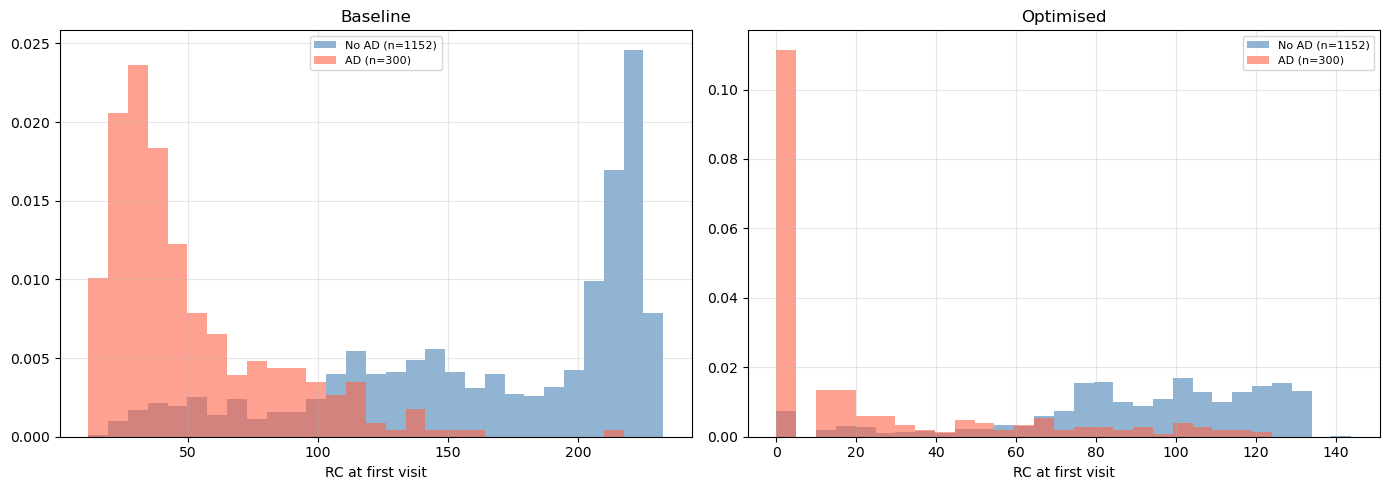

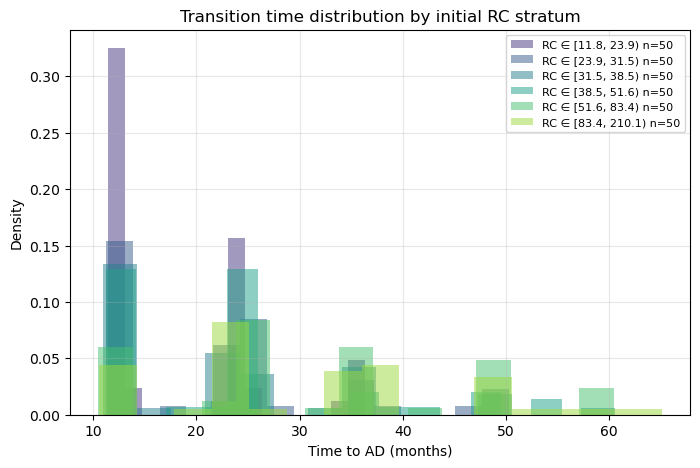

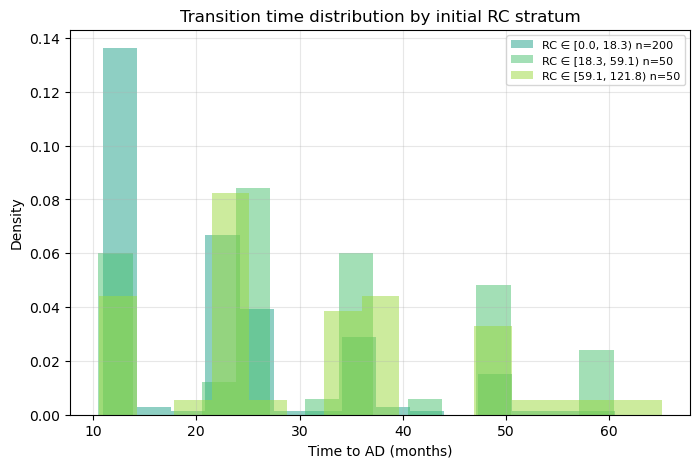

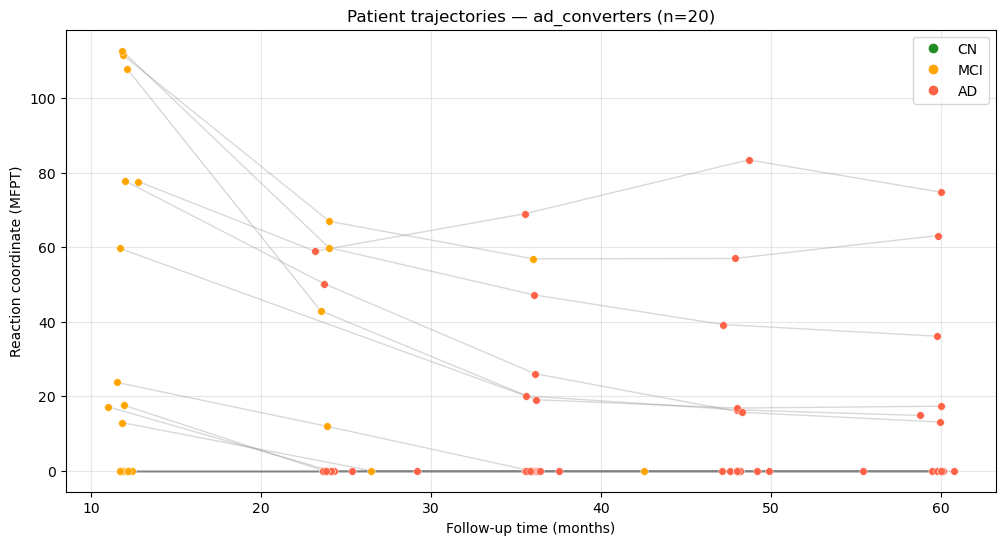

Found 13 patients matching criteria (MFPT ∈ [0, 300], mostly CN, late decline)
Showing 13 of them:

  RID   4121: RC₀=   88.1, 4 visits, slope=-0.80/month, path: CN → CN → MCI → MCI
  RID   1123: RC₀=  119.4, 5 visits, slope=-0.61/month, path: CN → CN → CN → MCI → MCI
  RID    106: RC₀=  118.9, 5 visits, slope=-0.14/month, path: CN → CN → CN → CN → MCI
  RID    778: RC₀=  115.6, 5 visits, slope=-1.39/month, path: CN → CN → CN → MCI → MCI
  RID    459: RC₀=  132.1, 5 visits, slope=-1.32/month, path: CN → CN → CN → MCI → MCI
  RID    972: RC₀=  129.2, 5 visits, slope=-1.64/month, path: CN → CN → CN → CN → MCI
  RID    127: RC₀=  127.4, 5 visits, slope=-0.59/month, path: CN → CN → CN → CN → MCI
  RID   4270: RC₀=  130.3, 4 visits, slope=-0.82/month, path: CN → CN → MCI → MCI
  RID   1169: RC₀=  125.6, 5 visits, slope=-0.30/month, path: CN → CN → CN → CN → MCI
  RID    622: RC₀=  101.6, 5 visits, slope=-0.98/month, path: CN → CN → CN → MCI → MCI
  RID   4100: RC₀=  105.3, 4 visits, slope=-

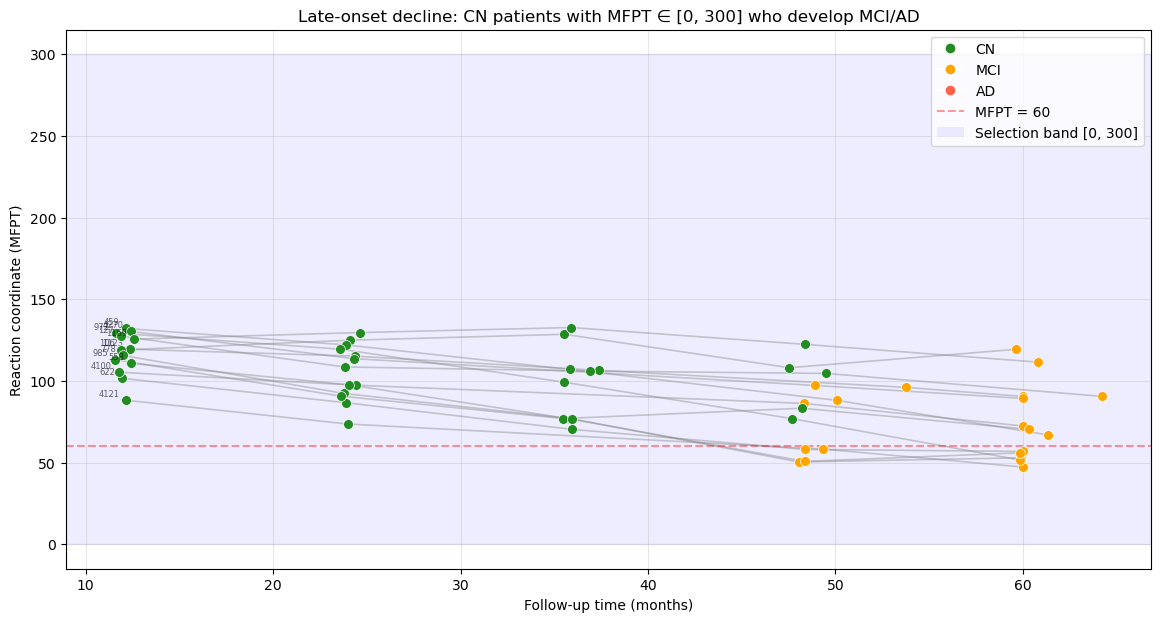


RC slope statistics (negative = RC decreasing toward AD):
  Mean: -0.870/month
  Patients with negative slope: 13/13
Seed 0 (np.seed=97071): C-index baseline=0.8927, optimised=0.8618, delta=-0.0309
Showing FEPs for seed idx=0, np.seed=97071

--- BASELINE (ML model seed_r) ---


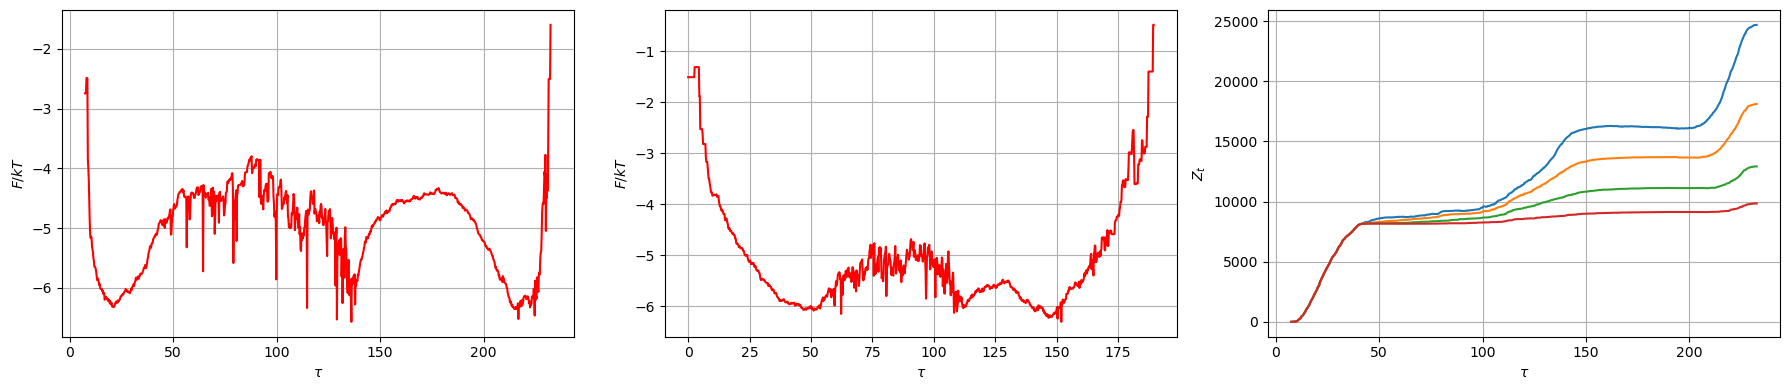

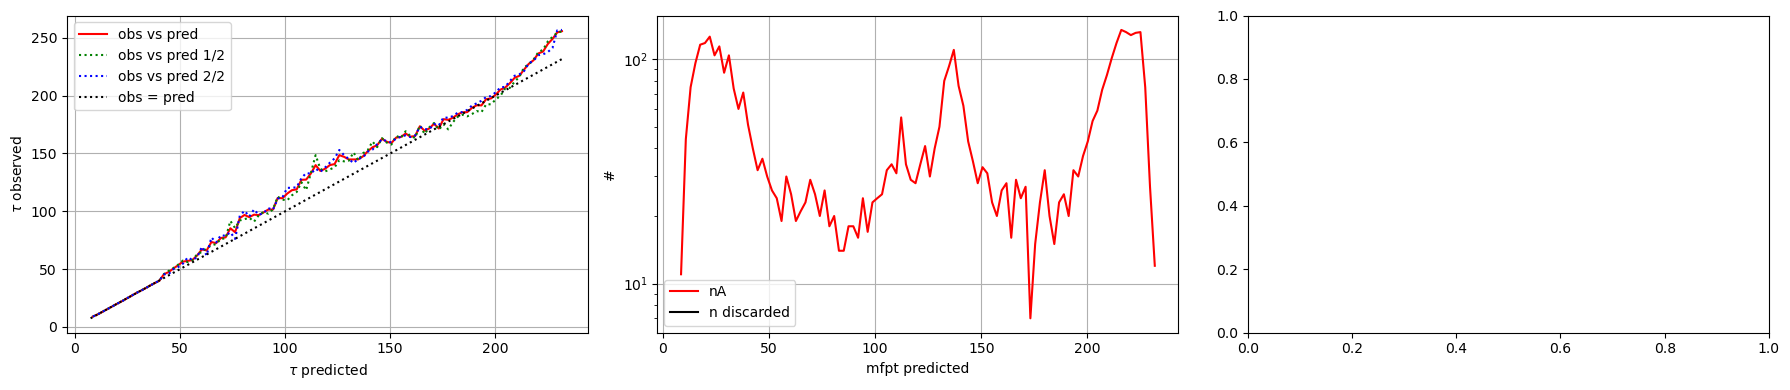


--- OPTIMISED ---


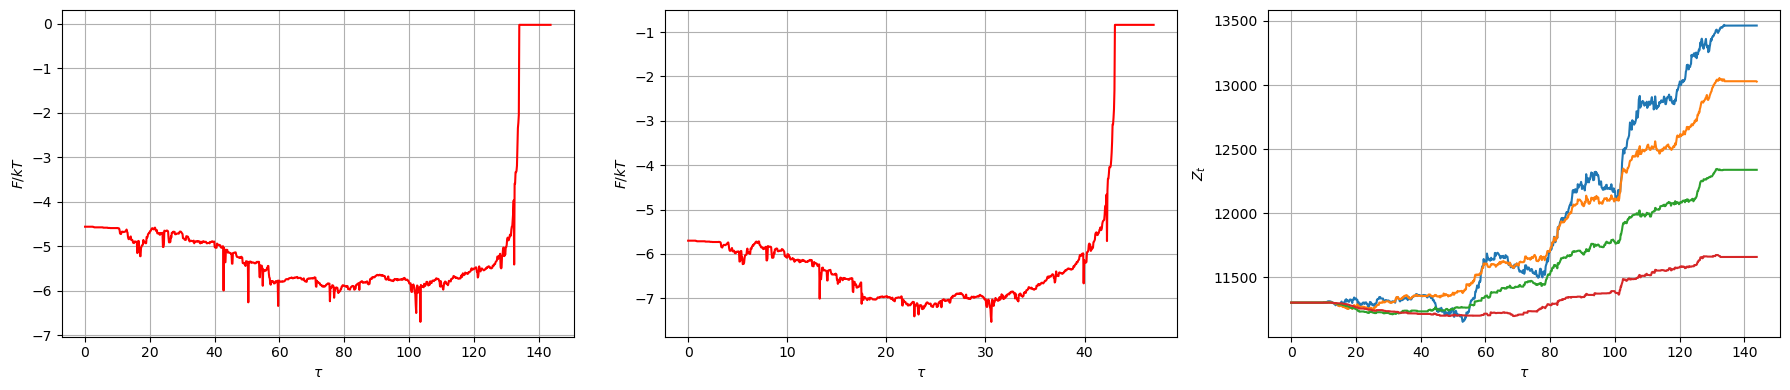

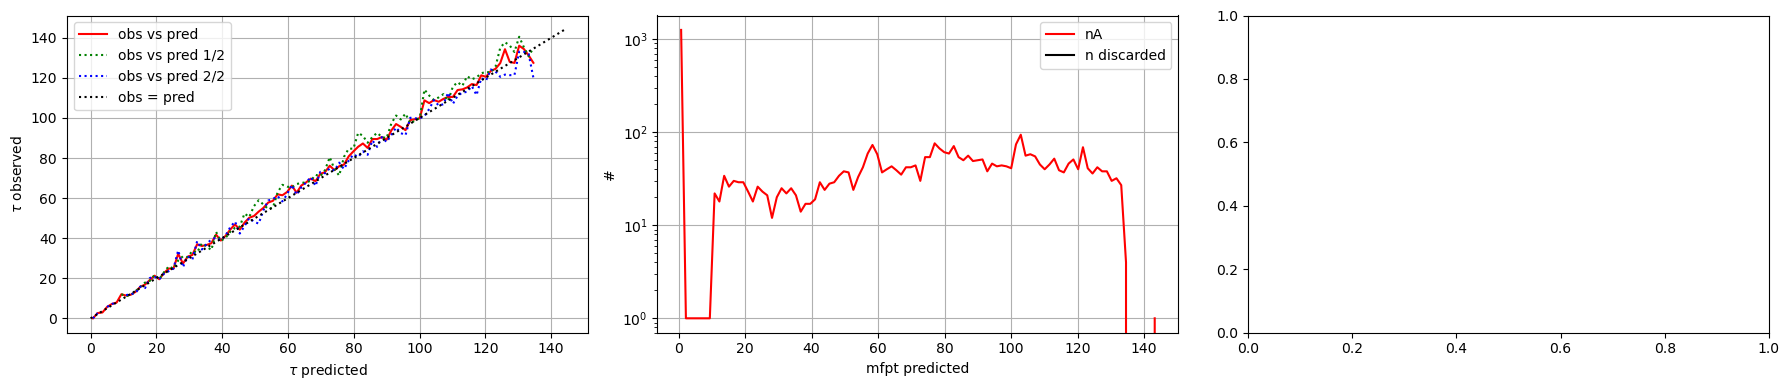

In [288]:
# ============================================================================
# STEP 1: SELECT THE BEST SEED
# ============================================================================
# The select_best_seed function computes Harrell's concordance index (C-index)
# for every optimised q object across all 60 seeds. The C-index measures how
# well the reaction coordinate orders pairs of patients by their time-to-AD:
# a value of 0.5 is random, 1.0 is perfect. It selects the seed whose
# optimised RC achieves the highest C-index, meaning it most accurately
# ranks patients by disease progression speed. The verbose output will show
# you the baseline C-index (same for all seeds since seed_r is fixed), the
# min/median/max across seeds, and the mean improvement. If all 60 seeds show
# positive improvement, that's strong evidence the optimisation genuinely
# captures signal rather than fitting noise.
# ============================================================================
best_idx = select_best_seed(results_model, df, criterion='best')
best_res = results_model[best_idx]

# ============================================================================
# STEP 2: KAPLAN-MEIER SURVIVAL CURVES — BASELINE vs OPTIMISED
# ============================================================================
# This is the centrepiece of the analysis. The function stratifies patients
# into 6 groups (sextiles) based on their reaction coordinate value at their
# FIRST visit, then computes the Kaplan-Meier survival function for each
# group — the probability of remaining AD-free as a function of follow-up
# time. Two panels are shown side by side: baseline (left) and optimised
# (right).
#
# HOW TO INTERPRET:
# A good reaction coordinate should produce well-separated survival curves.
# The lowest RC stratum (patients the model considers closest to AD) should
# show a steep survival drop — many patients converting quickly. The highest
# RC stratum should stay flat near 1.0 — almost no one converts. The strata
# in between should fan out in order between these extremes.
#
# WHAT TO LOOK FOR:
# Compare left vs right panels. If the optimised RC produces wider separation
# between the curves (especially in the middle strata that are hardest to
# distinguish), it means the optimisation has improved the model's ability
# to stratify patients by risk. With 6 bins instead of 4, you get finer
# resolution in the middle of the risk spectrum where clinical decisions
# are most uncertain.
#
# IMPORTANT CAVEAT:
# Because your data only has observations at 12, 24, 36, 48, and 60 months,
# the survival curves will be step functions with at most 5 drops. This is
# much coarser than typical clinical survival curves and limits how much
# visual separation you can see. The C-index is a more sensitive measure
# of improvement than the KM plot for your data.
# ============================================================================
plot_km_comparison(results_model, df, n_bins=6)

# ============================================================================
# STEP 3: KAPLAN-MEIER CONSISTENCY ACROSS SEEDS
# ============================================================================
# This plot checks whether the KM survival curves are robust across different
# random seeds, or whether the results are sensitive to the particular
# optimisation path taken. It creates one subplot per RC stratum (6 panels),
# and within each panel overlays the KM curves from all 60 seeds in
# semi-transparent lines.
#
# HOW TO INTERPRET:
# If the lines within each panel form a tight bundle, the optimisation
# consistently produces similar risk stratification regardless of the random
# seed — this is what you want to see and can report confidently. If the
# lines are widely spread (especially in middle strata), it means the
# coordinate is not well-constrained by the data in that risk region, and
# the optimisation is partially fitting noise.
#
# WHAT TO LOOK FOR:
# The extreme strata (lowest and highest risk) will likely show tight
# agreement because those patients are easy to classify. The middle strata
# are the interesting ones — spread there reveals where the model is most
# uncertain and where more data would help most.
# ============================================================================
plot_km_overlay_seeds(results_model, df, n_bins=6, which='optimised')

# ============================================================================
# STEP 4: LOG-RANK TEST — STATISTICAL SIGNIFICANCE OF STRATIFICATION
# ============================================================================
# The log-rank test quantifies what the KM plots show visually: is the
# difference between survival curves statistically significant? It computes
# a chi-squared statistic for every pair of adjacent strata, plus the total
# chi-squared across all pairs.
#
# HOW TO INTERPRET:
# Higher chi-squared = better separation = the RC is doing a better job of
# dividing patients into groups with genuinely different prognoses. A p-value
# below 0.05 means the difference is statistically significant. The total
# chi-squared is the single number to compare between baseline and optimised.
#
# WHAT TO LOOK FOR:
# The most informative comparison is between adjacent strata. It's easy for
# any reasonable RC to separate the extreme groups (very healthy vs very
# sick). The hard test is whether adjacent strata — patients who look
# similar — have significantly different outcomes. If the optimised RC
# produces significant p-values between adjacent strata where the baseline
# did not, that's a clear win.
#
# NOTE: compare_log_rank currently uses results[0] internally. You should
# edit it to use results[best_idx] for consistency with everything else.
# ============================================================================
lr_base, lr_opt = compare_log_rank(best_res, df, n_bins=6)

# ============================================================================
# STEP 5: INITIAL RC DISTRIBUTION BY OUTCOME — THREE-PANEL HISTOGRAM
# ============================================================================
# This shows three histograms of each patient's RC value at their first visit,
# coloured by whether they eventually developed AD (red) or not (blue).
#
# Left panel:   Baseline RC (full range, 0–60)
# Middle panel: Optimised RC (full range, 0–~1000) — shows the rescaling
# Right panel:  Optimised RC zoomed to [0, 60] — directly comparable to baseline
#
# HOW TO INTERPRET:
# A perfect RC would show zero overlap between the red and blue histograms —
# every AD converter would have a low RC value (close to the boundary) and
# every non-converter would have a high RC value (far from boundary). In
# practice there will always be overlap, but less overlap = better.
#
# WHAT TO LOOK FOR:
# The middle panel will show that the optimisation has pushed most non-
# converters (blue) far to the right (high MFPT values in the hundreds),
# while AD converters (red) remain clustered near zero. This dramatic
# rescaling is the optimisation doing its job — it's expanding the
# coordinate's dynamic range to better resolve the "safe" population.
#
# The right panel (zoomed) is the key comparison. Within the 0–60 range,
# are the red and blue distributions better separated after optimisation
# than in the baseline? The annotation in the corner tells you how many
# patients of each type were pushed above 60 by the optimisation — ideally
# almost all blue (non-converters) and almost no red (converters).
# ============================================================================
plot_rc_first_comparison(results_model, df)

# ============================================================================
# STEP 6: TRANSITION TIME DISTRIBUTIONS — BASELINE AND OPTIMISED
# ============================================================================
# These two plots show the distribution of actual observed times-to-AD for
# patients who did convert, stratified by their initial RC value. This is the
# MFPT analogue of the transition path time distribution from Krivov's
# framework.
#
# HOW TO INTERPRET:
# If the RC is a good MFPT estimator, then patients in the low-RC stratum
# should convert quickly (histogram peaked at early times like 12–24 months),
# while patients in the higher-RC strata should convert later (peaked at
# 48–60 months). The ordering of the histogram peaks should match the
# ordering of the RC strata.
#
# WHAT TO LOOK FOR:
# Compare the two plots. In the baseline, the distributions may overlap
# substantially — meaning the baseline RC doesn't cleanly separate fast
# converters from slow converters. If the optimised version shows less
# overlap and clearer ordering (each stratum's histogram shifted further
# right than the one below it), the optimisation has improved the model's
# ability to predict not just whether a patient will convert, but when.
#
# NOTE: Only patients who actually reached AD appear in these histograms.
# Non-converters are excluded because we don't know their time-to-AD.
# ============================================================================
plot_tpt_distribution(best_res['q_original'].r_traj, df, n_bins=6)
plot_tpt_distribution(best_res['q_optimised'].r_traj, df, n_bins=6)

# ============================================================================
# STEP 7: PATIENT TRAJECTORIES — AD CONVERTERS
# ============================================================================
# This plot shows individual patient journeys on the reaction coordinate over
# time. Each trajectory is a line connecting a single patient's visits, with
# points coloured by their clinical diagnosis at that visit: green for CN
# (cognitively normal), orange for MCI (mild cognitive impairment), and red
# for AD (Alzheimer's disease). Only patients who started as CN or MCI and
# eventually reached AD are shown — these are the "interesting" cases where
# you can see disease progression reflected in the RC.
#
# HOW TO INTERPRET:
# If the RC is capturing disease dynamics well, you should see trajectories
# that move downward (decreasing MFPT = getting closer to AD) over time,
# with the colour transitions matching: green points at the top, orange in
# the middle, red at the bottom. The trajectories should look like patients
# "sliding down" the free energy landscape toward the AD boundary.
#
# WHAT TO LOOK FOR:
# Look for whether the RC starts decreasing before the clinical diagnosis
# changes — for example, a patient who is still clinically CN (green) but
# whose RC is already drifting downward. This would mean the optimised
# coordinate is detecting prodromal decline that precedes the formal
# diagnostic label, which is exactly the kind of insight that justifies
# using the MFPT framework rather than a simple classifier.
#
# If trajectories are flat until the diagnosis changes and then jump
# abruptly, the RC is essentially just reflecting the classification
# labels rather than capturing continuous underlying dynamics.
# ============================================================================
plot_patient_trajectories(best_res['q_optimised'].r_traj, df,
                          n_patients=20, trajectory_type='ad_converters')

# ============================================================================
# STEP 8: LATE-ONSET TRAJECTORIES — THE EXTRAPOLATION TEST
# ============================================================================
# This is the most novel analysis and potentially the most interesting for
# your report. It searches for patients who satisfy three criteria
# simultaneously: (1) their initial MFPT is between 60 and 300 months,
# meaning the optimised model considers them well beyond the 60-month
# clinical observation window; (2) they are predominantly diagnosed as CN
# across their trajectory; and (3) they develop MCI or AD near the end of
# their observed visits.
#
# WHY THIS MATTERS:
# These patients test whether the MFPT coordinate is making meaningful
# predictions in the extrapolation regime — beyond the 60-month window
# that the original ML model was trained on. A patient with MFPT = 150
# months is being told "you're roughly 12.5 years from AD." If that patient
# then shows signs of cognitive decline within 5 years, it could mean the
# coordinate is wrong about their timing, OR it could mean the coordinate
# correctly identified them as eventually progressing but on a longer
# timescale than their current clinical trajectory suggests.
#
# HOW TO INTERPRET:
# The printed output shows each patient's diagnostic path (e.g.,
# CN → CN → CN → MCI) and the RC slope over time. A negative slope means
# the RC was decreasing visit-over-visit even while the patient was still
# clinically CN — this is the key finding. It would mean the optimised
# coordinate was detecting subtle decline dynamics before the clinical
# diagnosis caught up, which is strong evidence for the value of the MFPT
# framework.
#
# The blue shaded band shows the MFPT selection window, and the red dashed
# line at 60 marks the boundary of the clinical observation period. Patients
# whose trajectories start in the blue band but arc downward toward the red
# line are the most compelling cases for your report.
#
# If zero patients are found, try widening the range (e.g., mfpt_lower=40)
# or check whether your cohort simply doesn't contain CN patients who later
# develop MCI — this would be a data limitation, not a method failure.
# ============================================================================
plot_late_onset_trajectories(best_res['q_optimised'].r_traj, df,
                              mfpt_lower=0, mfpt_upper=300, n_patients=30)

# ============================================================================
# STEP 9: CONCORDANCE INDEX — SUMMARY DISCRIMINATION METRIC
# ============================================================================
# This prints the C-index for every seed, showing baseline vs optimised and
# the delta. The C-index is the single most important number for your report
# because it uses the full continuous RC without binning and evaluates all
# pairwise patient orderings.
#
# HOW TO INTERPRET:
# A C-index of 0.89 (baseline) means the ML model's raw output correctly
# orders 89% of patient pairs by time-to-AD. If every seed shows a positive
# delta (improvement), and the deltas cluster tightly (e.g., all between
# +0.03 and +0.04), you can make a strong claim that the optimisation
# genuinely improves the model. The consistency across seeds is the key
# argument against overfitting — if the improvement were due to noise, you
# would expect some seeds to show negative deltas.
#
# FOR YOUR REPORT:
# Report the baseline C-index, the mean and range of optimised C-indices,
# and the mean improvement. This is the quantitative backbone of your
# conclusion that optimalrcs improves the ML model's prognostic value.
# ============================================================================
compare_concordance(results_model, df)

# ============================================================================
# STEP 10: FREE ENERGY PROFILES — BEST SEED DIAGNOSTICS
# ============================================================================
# This shows the standard optimalrcs diagnostic plots for the selected best
# seed: free energy profiles (FEPs) and the observed-vs-predicted comparison
# at multiple lag times, for both baseline and optimised.
#
# HOW TO INTERPRET THE FEPs:
# The free energy profile F(r) = -ln P(r) shows how the probability density
# is distributed along the reaction coordinate. Minima correspond to
# metastable states (e.g., "stable CN" and "stable AD"), and barriers
# between them correspond to transition states (the point of no return in
# disease progression). A well-optimised RC should produce a clear barrier
# between a CN-like minimum and the AD boundary, with the barrier height
# reflecting how difficult the CN→AD transition is.
#
# The three lines at different lag times should overlap if the coordinate is
# Markovian (memoryless). Separation between them means the projected
# dynamics has memory effects — the coordinate is suboptimal at those
# timescales. Compare baseline (where the lines will likely diverge) vs
# optimised (where they should converge).
#
# HOW TO INTERPRET OBS VS PRED:
# This plot compares the observed MFPT (computed directly from patient
# trajectories) against the predicted MFPT (derived from the free energy
# profile under the diffusion model). Points should scatter around the
# diagonal (obs = pred). In the baseline, you previously saw a mismatch
# due to the RC being on the wrong scale. After optimisation, the points
# should cluster much more tightly around the diagonal, confirming that the
# optimised coordinate produces a self-consistent diffusive description of
# the disease dynamics.
# ============================================================================
plot_best_seed_feps(results_model, best_idx, lag_times)

In [273]:
# ============================================================================
# BOOTSTRAPPING FUNCTIONS
# ============================================================================
# These functions implement the bootstrapping approach from Krivov's
# experimental-testing notebook, adapted for the MFPT framework. The core
# idea is that each seed in results_model produces a different optimised
# reaction coordinate. By overlaying these across seeds, we get uncertainty
# estimates for every quantity we compute — from individual patient risk
# scores to population-level survival curves.
#
# This is NOT the same as statistical bootstrapping (resampling with
# replacement from the data). It is optimisation bootstrapping: each seed
# takes a different random path through the polynomial optimisation space,
# arriving at a slightly different coordinate. The spread across seeds
# reflects the inherent ambiguity in the data — how much the data
# constrains the reaction coordinate.
# ============================================================================


def plot_patient_bootstrap(results, df, patient_id, n_seeds=None,
                           highlight_best=None):
    """
    Overlay RC trajectories from multiple optimisation seeds for a single
    patient, showing the uncertainty band around their disease progression.
    
    This is the MFPT adaptation of experimental.plots_patient_bootstrap_id
    from Krivov's notebook.
    
    Parameters:
        results:        output of mfpt_model()
        df:             your dataframe
        patient_id:     RID of the patient to plot
        n_seeds:        how many seeds to overlay (None = all)
        highlight_best: index of the best seed to draw in bold
    """
    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy().astype(float)
    dx_traj = df['FollowupDX'].to_numpy()

    # Find this patient's visits
    idx = np.where(i_traj_np == patient_id)[0]
    if len(idx) == 0:
        print(f"Patient {patient_id} not found.")
        return

    times = t_traj_np[idx]
    dx_vals = dx_traj[idx]
    dx_labels = {0: 'CN', 1: 'MCI', 2: 'AD'}
    dx_colors = {0: 'forestgreen', 1: 'orange', 2: 'tomato'}

    # Select which seeds to use
    if n_seeds is None:
        seed_indices = range(len(results))
    else:
        seed_indices = np.linspace(0, len(results) - 1,
                                   min(n_seeds, len(results)), dtype=int)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Left panel: all seeds overlaid as individual lines ---
    all_rc = []
    for si in seed_indices:
        r_traj = results[si]['q_optimised'].r_traj
        if hasattr(r_traj, 'get'):
            r_traj = r_traj.get()
        rc_vals = np.asarray(r_traj, dtype=float)[idx]
        all_rc.append(rc_vals)

        is_best = (highlight_best is not None and si == highlight_best)
        alpha = 0.8 if is_best else 0.15
        lw = 2.5 if is_best else 0.8
        zorder = 10 if is_best else 1
        ax1.plot(times, rc_vals, '-', color='steelblue', alpha=alpha,
                 linewidth=lw, zorder=zorder)

    # Colour the diagnosis points on the best seed's trajectory
    if highlight_best is not None:
        best_rc = all_rc[list(seed_indices).index(highlight_best)
                         ] if highlight_best in seed_indices else all_rc[0]
    else:
        best_rc = all_rc[0]

    for t, r, dx in zip(times, best_rc, dx_vals):
        ax1.scatter(t, r, color=dx_colors[dx], s=60, zorder=11,
                    edgecolors='white', linewidths=0.5)

    ax1.axhline(y=60, color='red', linestyle='--', alpha=0.3,
                label='MFPT = 60')
    ax1.set_xlabel('Follow-up time (months)')
    ax1.set_ylabel('Reaction coordinate (MFPT)')
    dx_path = ' → '.join([dx_labels[d] for d in dx_vals])
    ax1.set_title(f'Patient {int(patient_id)} — {len(list(seed_indices))} '
                  f'seeds overlaid\n{dx_path}')
    ax1.grid(True, alpha=0.3)

    # --- Right panel: mean ± std envelope ---
    all_rc = np.array(all_rc)  # shape: (n_seeds, n_visits)
    rc_mean = all_rc.mean(axis=0)
    rc_std = all_rc.std(axis=0)
    rc_min = all_rc.min(axis=0)
    rc_max = all_rc.max(axis=0)

    ax2.fill_between(times, rc_min, rc_max, alpha=0.15, color='steelblue',
                     label='Min–Max range')
    ax2.fill_between(times, rc_mean - rc_std, rc_mean + rc_std,
                     alpha=0.3, color='steelblue', label='±1 std')
    ax2.plot(times, rc_mean, '-', color='steelblue', linewidth=2,
             label='Mean across seeds')

    for t, r_m, dx in zip(times, rc_mean, dx_vals):
        ax2.scatter(t, r_m, color=dx_colors[dx], s=60, zorder=5,
                    edgecolors='white', linewidths=0.5)

    ax2.axhline(y=60, color='red', linestyle='--', alpha=0.3)
    ax2.set_xlabel('Follow-up time (months)')
    ax2.set_ylabel('Reaction coordinate (MFPT)')
    ax2.set_title(f'Patient {int(patient_id)} — mean ± uncertainty')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\nPatient {int(patient_id)} bootstrap summary:")
    print(f"  Diagnosis path: {dx_path}")
    for v, (t, dx) in enumerate(zip(times, dx_vals)):
        print(f"  Visit {v+1} (t={t:.0f}m, {dx_labels[dx]}): "
              f"RC = {rc_mean[v]:.1f} ± {rc_std[v]:.1f} "
              f"[{rc_min[v]:.1f} – {rc_max[v]:.1f}]")


def plot_bootstrap_multi_patients(results, df, patient_ids=None,
                                   n_patients=6, n_seeds=None,
                                   trajectory_type='converters',
                                   seed=42, highlight_best=None):
    """
    Grid of bootstrap plots for multiple patients. Automatically selects
    interesting patients if patient_ids is not provided.
    
    Parameters:
        results:         output of mfpt_model()
        df:              your dataframe
        patient_ids:     list of RIDs to plot, or None for auto-selection
        n_patients:      how many patients if auto-selecting
        n_seeds:         how many seeds to overlay (None = all)
        trajectory_type: 'converters', 'ad_converters', or 'late_onset'
        seed:            random seed for patient selection
        highlight_best:  index of best seed to draw bold
    """
    i_traj_np = df['RID'].to_numpy()
    dx_traj = df['FollowupDX'].to_numpy()

    # --- Auto-select patients if not provided ---
    if patient_ids is None:
        unique_ids = np.unique(i_traj_np)
        candidates = []

        for pid in unique_ids:
            idx = np.where(i_traj_np == pid)[0]
            if len(idx) < 3:
                continue
            dx_vals = dx_traj[idx]
            dx_changes = np.sum(np.diff(dx_vals) != 0)

            if trajectory_type == 'converters' and dx_changes > 0:
                candidates.append((pid, dx_changes))
            elif trajectory_type == 'ad_converters':
                if np.any(dx_vals == 2) and dx_vals[0] < 2:
                    candidates.append((pid, dx_changes))
            elif trajectory_type == 'late_onset':
                # Get RC from first result to check MFPT range
                r = results[0]['q_optimised'].r_traj
                if hasattr(r, 'get'):
                    r = r.get()
                r_first = np.asarray(r, dtype=float)[idx[0]]
                if (r_first > 60 and dx_vals[0] == 0
                        and dx_vals[-1] > 0 and dx_changes > 0):
                    candidates.append((pid, dx_changes))

        if not candidates:
            print(f"No patients found for trajectory_type='{trajectory_type}'")
            return

        candidates.sort(key=lambda x: -x[1])
        rng = np.random.RandomState(seed)
        pool = [c[0] for c in candidates[:max(n_patients * 3, len(candidates))]]
        patient_ids = rng.choice(pool,
                                 size=min(n_patients, len(pool)),
                                 replace=False)

    # --- Plot each patient ---
    for pid in patient_ids:
        plot_patient_bootstrap(results, df, patient_id=pid,
                               n_seeds=n_seeds,
                               highlight_best=highlight_best)


def plot_bootstrap_summary_stats(results, df):
    """
    Population-level bootstrapping: show the distribution of key metrics
    across all seeds. This tells you how robust your conclusions are.
    
    Produces three panels:
      - C-index distribution across seeds
      - Total log-rank chi-squared distribution across seeds  
      - Histogram of per-patient RC standard deviation across seeds
    """
    i_traj_np = df['RID'].to_numpy()
    t_traj_np = df['delta_t'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()

    # --- Compute C-index for each seed ---
    c_indices = []
    for res in results:
        c = concordance_index(res['q_optimised'].r_traj, df)
        c_indices.append(c)
    c_indices = np.array(c_indices)
    baseline_c = concordance_index(results[0]['q_original'].r_traj, df)

    # --- Compute total log-rank chi2 for each seed ---
    lr_chi2s = []
    for res in results:
        km = compute_km_data(res['q_optimised'].r_traj, i_traj_np,
                             t_traj_np, boundary, n_bins=4)
        lr = log_rank_test(km)
        lr_chi2s.append(lr['chi2'].sum())
    lr_chi2s = np.array(lr_chi2s)

    # Baseline log-rank
    km_base = compute_km_data(results[0]['q_original'].r_traj, i_traj_np,
                              t_traj_np, boundary, n_bins=4)
    lr_base = log_rank_test(km_base)
    baseline_lr = lr_base['chi2'].sum()

    # --- Compute per-patient RC uncertainty ---
    # For each patient, compute std of their first-visit RC across seeds
    unique_ids = np.unique(i_traj_np)
    patient_stds = []
    for pid in unique_ids:
        idx = np.where(i_traj_np == pid)[0]
        first_rcs = []
        for res in results:
            r = res['q_optimised'].r_traj
            if hasattr(r, 'get'):
                r = r.get()
            first_rcs.append(np.asarray(r, dtype=float)[idx[0]])
        patient_stds.append(np.std(first_rcs))
    patient_stds = np.array(patient_stds)

    # --- Plot ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

    # Panel 1: C-index distribution
    ax1.hist(c_indices, bins=20, alpha=0.7, color='steelblue',
             edgecolor='white')
    ax1.axvline(baseline_c, color='tomato', linestyle='--', linewidth=2,
                label=f'Baseline: {baseline_c:.4f}')
    ax1.axvline(c_indices.mean(), color='navy', linestyle='-', linewidth=2,
                label=f'Mean optimised: {c_indices.mean():.4f}')
    ax1.set_xlabel('C-index')
    ax1.set_ylabel('Count (seeds)')
    ax1.set_title(f'C-index across {len(results)} seeds')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # Panel 2: Log-rank chi2 distribution
    ax2.hist(lr_chi2s, bins=20, alpha=0.7, color='steelblue',
             edgecolor='white')
    ax2.axvline(baseline_lr, color='tomato', linestyle='--', linewidth=2,
                label=f'Baseline: {baseline_lr:.1f}')
    ax2.axvline(lr_chi2s.mean(), color='navy', linestyle='-', linewidth=2,
                label=f'Mean optimised: {lr_chi2s.mean():.1f}')
    ax2.set_xlabel('Total log-rank χ²')
    ax2.set_ylabel('Count (seeds)')
    ax2.set_title(f'Risk stratification strength across {len(results)} seeds')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

    # Panel 3: Per-patient RC uncertainty
    ax3.hist(patient_stds, bins=30, alpha=0.7, color='steelblue',
             edgecolor='white')
    ax3.set_xlabel('Std of first-visit RC across seeds')
    ax3.set_ylabel('Count (patients)')
    ax3.set_title(f'Per-patient RC uncertainty (n={len(patient_stds)} patients)')
    ax3.grid(True, alpha=0.3)

    # Annotate with summary stats
    ax3.annotate(
        f'Median: {np.median(patient_stds):.1f}\n'
        f'Mean: {np.mean(patient_stds):.1f}\n'
        f'90th pctl: {np.percentile(patient_stds, 90):.1f}',
        xy=(0.95, 0.95), xycoords='axes fraction',
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

    plt.suptitle('Bootstrap summary — optimisation robustness', fontsize=12)
    plt.tight_layout()
    plt.show()

    # Print summary
    n_improved = np.sum(c_indices > baseline_c)
    n_lr_improved = np.sum(lr_chi2s > baseline_lr)
    print(f"\nBootstrap summary across {len(results)} seeds:")
    print(f"  C-index: {n_improved}/{len(results)} seeds improved over "
          f"baseline ({100*n_improved/len(results):.0f}%)")
    print(f"  C-index range: [{c_indices.min():.4f}, {c_indices.max():.4f}], "
          f"mean improvement: +{c_indices.mean() - baseline_c:.4f}")
    print(f"  Log-rank χ²: {n_lr_improved}/{len(results)} seeds improved "
          f"over baseline ({100*n_lr_improved/len(results):.0f}%)")
    print(f"  Per-patient RC std: median={np.median(patient_stds):.1f}, "
          f"mean={np.mean(patient_stds):.1f}")

def plot_bootstrap_uncertainty_by_outcome(results, df):
    """
    Stratify the per-patient RC uncertainty by clinical outcome.
    
    The hypothesis is that patients who convert to AD have tightly
    constrained RC values (the data strongly determines their position
    near the boundary), while patients who remain CN sit in the flat
    plateau of the free energy landscape where different seeds can
    place them at very different positions without affecting the
    overall ranking quality.
    """
    i_traj_np = df['RID'].to_numpy()
    dx_traj = df['FollowupDX'].to_numpy()
    boundary = (df['FollowupDX'] == 2).to_numpy()
    unique_ids = np.unique(i_traj_np)

    # --- Classify each patient by their trajectory type ---
    patient_info = {}
    for pid in unique_ids:
        idx = np.where(i_traj_np == pid)[0]
        dx_vals = dx_traj[idx]
        
        # Determine trajectory category
        if np.all(dx_vals == 0):
            category = 'Stable CN'
        elif np.all(dx_vals == 1):
            category = 'Stable MCI'
        elif np.any(dx_vals == 2) and dx_vals[0] < 2:
            category = 'Converter to AD'
        elif dx_vals[0] == 0 and np.any(dx_vals == 1):
            category = 'CN → MCI'
        else:
            category = 'Other'

        patient_info[pid] = {
            'idx': idx,
            'category': category,
        }

    # --- Compute per-patient RC statistics across seeds ---
    for pid in unique_ids:
        first_rcs = []
        for res in results:
            r = res['q_optimised'].r_traj
            if hasattr(r, 'get'):
                r = r.get()
            first_rcs.append(np.asarray(r, dtype=float)[patient_info[pid]['idx'][0]])
        
        first_rcs = np.array(first_rcs)
        patient_info[pid]['rc_mean'] = first_rcs.mean()
        patient_info[pid]['rc_std'] = first_rcs.std()
        patient_info[pid]['rc_cv'] = first_rcs.std() / max(abs(first_rcs.mean()), 1e-6)

    # --- Organise by category ---
    categories = ['Stable CN', 'CN → MCI', 'Stable MCI', 'Converter to AD', 'Other']
    cat_colors = {
        'Stable CN': 'forestgreen',
        'CN → MCI': 'goldenrod',
        'Stable MCI': 'orange',
        'Converter to AD': 'tomato',
        'Other': 'grey',
    }

    # Filter to categories that actually exist in the data
    categories = [c for c in categories
                  if any(v['category'] == c for v in patient_info.values())]

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # --- Panel 1: Absolute std by category (box plot) ---
    box_data = []
    box_labels = []
    box_colors = []
    for cat in categories:
        stds = [v['rc_std'] for v in patient_info.values() if v['category'] == cat]
        if stds:
            box_data.append(stds)
            n = len(stds)
            box_labels.append(f'{cat}\n(n={n})')
            box_colors.append(cat_colors[cat])

    bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True,
                     widths=0.6, showfliers=False)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax1.set_ylabel('RC standard deviation across seeds')
    ax1.set_title('Absolute RC uncertainty by outcome group')
    ax1.grid(True, alpha=0.3, axis='y')

    # --- Panel 2: Coefficient of variation by category ---
    box_data_cv = []
    for cat in categories:
        cvs = [v['rc_cv'] for v in patient_info.values() if v['category'] == cat]
        if cvs:
            box_data_cv.append(cvs)

    bp2 = ax2.boxplot(box_data_cv, labels=box_labels, patch_artist=True,
                      widths=0.6, showfliers=False)
    for patch, color in zip(bp2['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax2.set_ylabel('Coefficient of variation (std / |mean|)')
    ax2.set_title('Relative RC uncertainty by outcome group')
    ax2.grid(True, alpha=0.3, axis='y')

    # --- Panel 3: Scatter of mean RC vs std, coloured by outcome ---
    for cat in categories:
        means = [v['rc_mean'] for v in patient_info.values() if v['category'] == cat]
        stds = [v['rc_std'] for v in patient_info.values() if v['category'] == cat]
        ax3.scatter(means, stds, alpha=0.5, s=20, color=cat_colors[cat],
                    label=cat, edgecolors='white', linewidths=0.3)
    ax3.set_xlabel('Mean RC across seeds')
    ax3.set_ylabel('RC std across seeds')
    ax3.set_title('Uncertainty vs predicted risk')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    # --- Panel 4: Overlaid histograms of std by category ---
    for cat in categories:
        stds = [v['rc_std'] for v in patient_info.values() if v['category'] == cat]
        if stds:
            ax4.hist(stds, bins=25, alpha=0.5, density=True,
                     color=cat_colors[cat], label=cat)
    ax4.set_xlabel('RC standard deviation across seeds')
    ax4.set_ylabel('Density')
    ax4.set_title('Distribution of RC uncertainty by outcome')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Bootstrap uncertainty stratified by clinical outcome', fontsize=13)
    plt.tight_layout()
    plt.show()

    # --- Print summary table ---
    print(f"\n{'Category':<20} {'n':>5} {'RC mean':>10} {'RC std':>10} "
          f"{'CV':>8} {'Std median':>12} {'Std 90th':>10}")
    print('-' * 80)
    for cat in categories:
        entries = [v for v in patient_info.values() if v['category'] == cat]
        if not entries:
            continue
        n = len(entries)
        rc_means = [e['rc_mean'] for e in entries]
        rc_stds = [e['rc_std'] for e in entries]
        cvs = [e['rc_cv'] for e in entries]
        print(f"{cat:<20} {n:>5} {np.mean(rc_means):>10.1f} "
              f"{np.mean(rc_stds):>10.1f} {np.mean(cvs):>8.3f} "
              f"{np.median(rc_stds):>12.1f} {np.percentile(rc_stds, 90):>10.1f}")

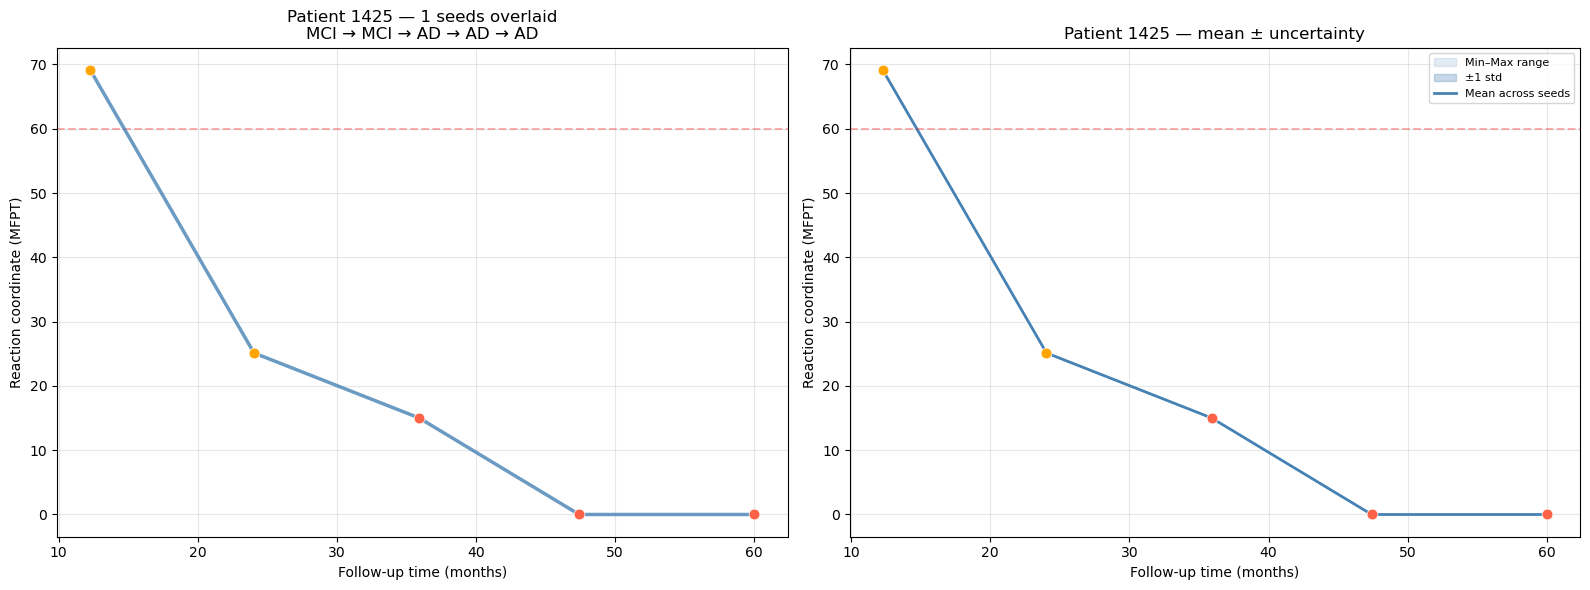


Patient 1425 bootstrap summary:
  Diagnosis path: MCI → MCI → AD → AD → AD
  Visit 1 (t=12m, MCI): RC = 69.1 ± 0.0 [69.1 – 69.1]
  Visit 2 (t=24m, MCI): RC = 25.1 ± 0.0 [25.1 – 25.1]
  Visit 3 (t=36m, AD): RC = 15.0 ± 0.0 [15.0 – 15.0]
  Visit 4 (t=47m, AD): RC = 0.0 ± 0.0 [0.0 – 0.0]
  Visit 5 (t=60m, AD): RC = 0.0 ± 0.0 [0.0 – 0.0]


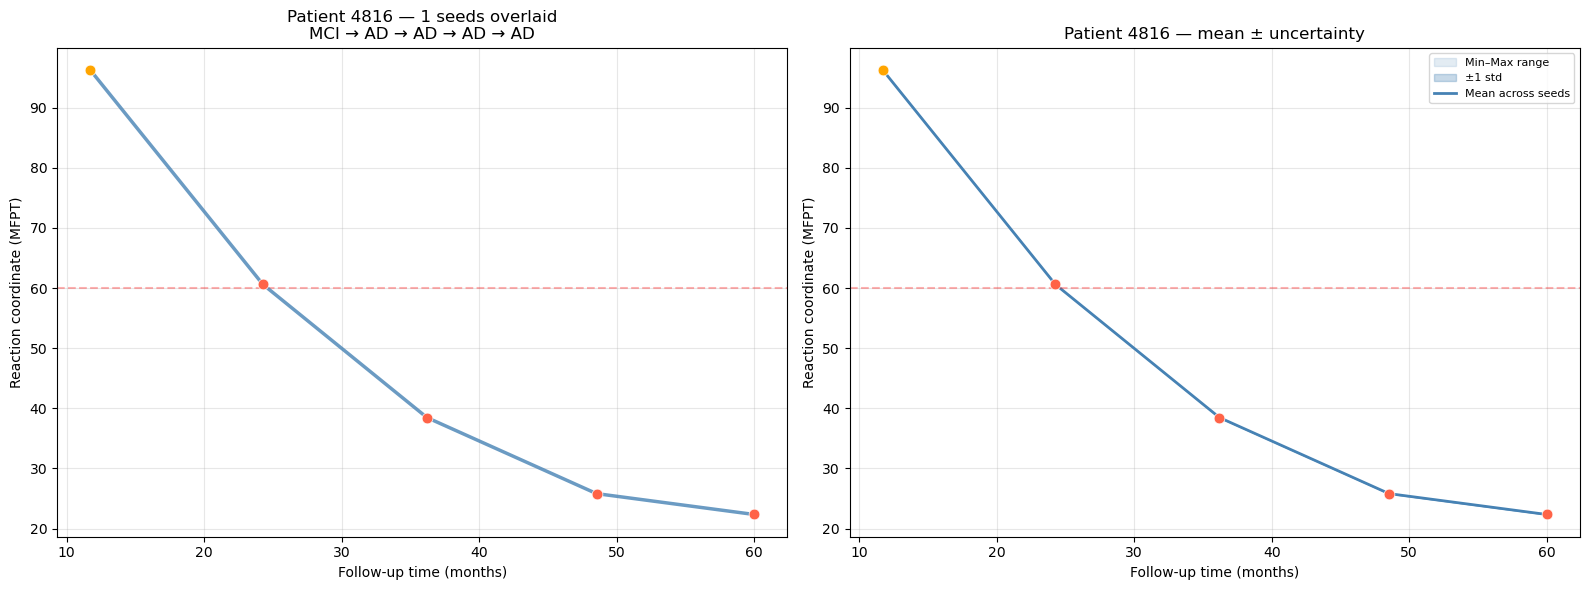


Patient 4816 bootstrap summary:
  Diagnosis path: MCI → AD → AD → AD → AD
  Visit 1 (t=12m, MCI): RC = 96.3 ± 0.0 [96.3 – 96.3]
  Visit 2 (t=24m, AD): RC = 60.6 ± 0.0 [60.6 – 60.6]
  Visit 3 (t=36m, AD): RC = 38.5 ± 0.0 [38.5 – 38.5]
  Visit 4 (t=49m, AD): RC = 25.8 ± 0.0 [25.8 – 25.8]
  Visit 5 (t=60m, AD): RC = 22.3 ± 0.0 [22.3 – 22.3]


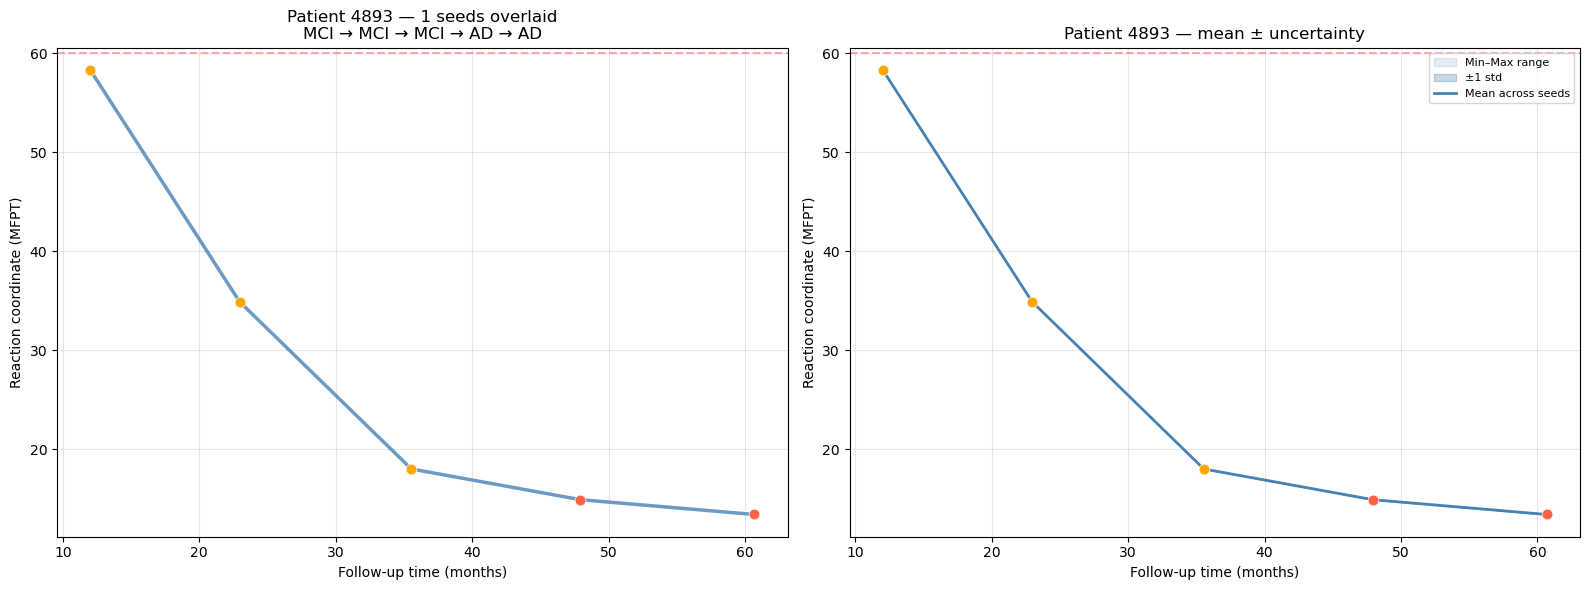


Patient 4893 bootstrap summary:
  Diagnosis path: MCI → MCI → MCI → AD → AD
  Visit 1 (t=12m, MCI): RC = 58.3 ± 0.0 [58.3 – 58.3]
  Visit 2 (t=23m, MCI): RC = 34.9 ± 0.0 [34.9 – 34.9]
  Visit 3 (t=36m, MCI): RC = 18.0 ± 0.0 [18.0 – 18.0]
  Visit 4 (t=48m, AD): RC = 14.9 ± 0.0 [14.9 – 14.9]
  Visit 5 (t=61m, AD): RC = 13.4 ± 0.0 [13.4 – 13.4]


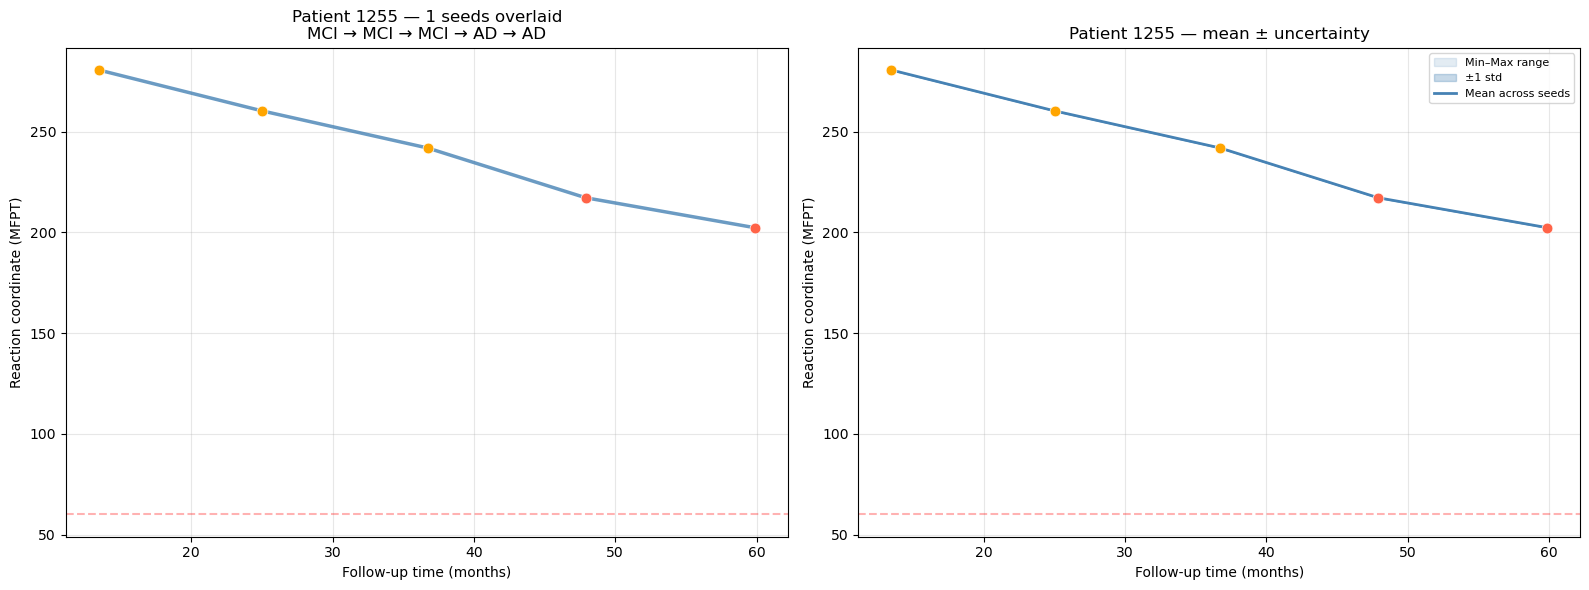


Patient 1255 bootstrap summary:
  Diagnosis path: MCI → MCI → MCI → AD → AD
  Visit 1 (t=13m, MCI): RC = 280.6 ± 0.0 [280.6 – 280.6]
  Visit 2 (t=25m, MCI): RC = 260.3 ± 0.0 [260.3 – 260.3]
  Visit 3 (t=37m, MCI): RC = 241.9 ± 0.0 [241.9 – 241.9]
  Visit 4 (t=48m, AD): RC = 217.2 ± 0.0 [217.2 – 217.2]
  Visit 5 (t=60m, AD): RC = 202.3 ± 0.0 [202.3 – 202.3]


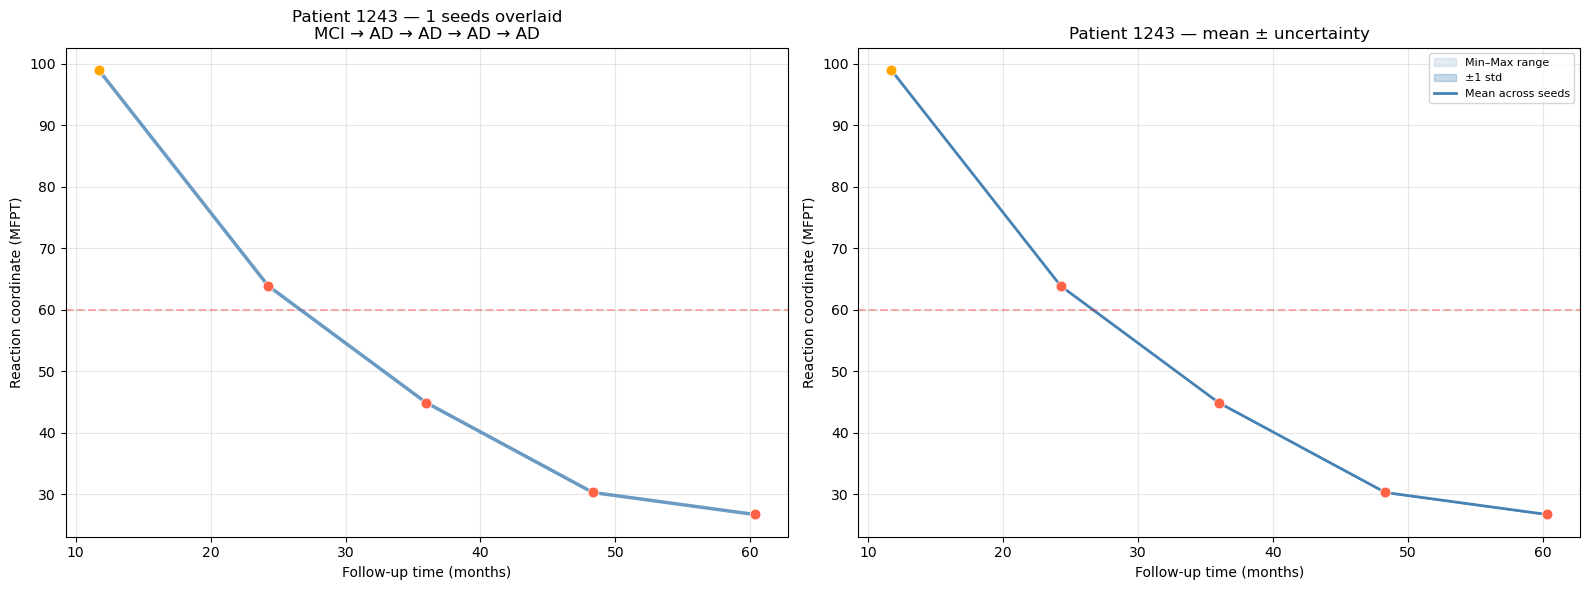


Patient 1243 bootstrap summary:
  Diagnosis path: MCI → AD → AD → AD → AD
  Visit 1 (t=12m, MCI): RC = 99.0 ± 0.0 [99.0 – 99.0]
  Visit 2 (t=24m, AD): RC = 63.9 ± 0.0 [63.9 – 63.9]
  Visit 3 (t=36m, AD): RC = 44.9 ± 0.0 [44.9 – 44.9]
  Visit 4 (t=48m, AD): RC = 30.3 ± 0.0 [30.3 – 30.3]
  Visit 5 (t=60m, AD): RC = 26.7 ± 0.0 [26.7 – 26.7]


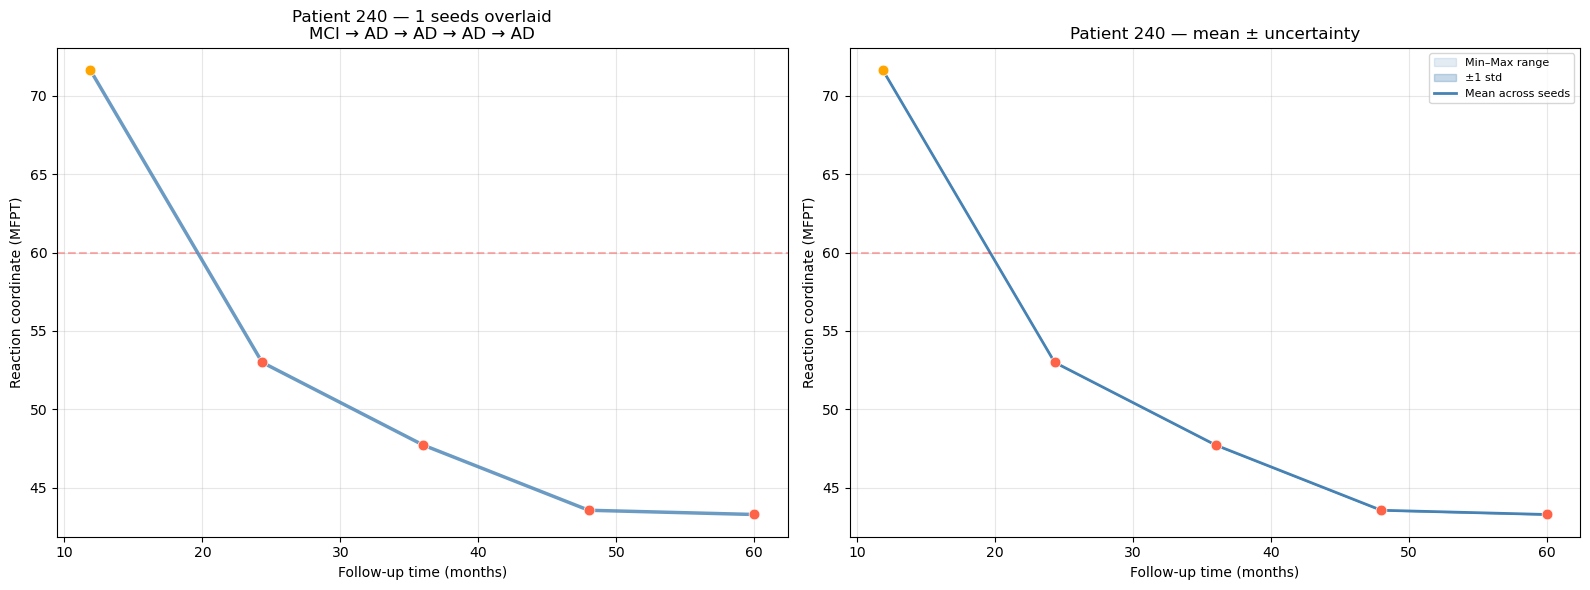


Patient 240 bootstrap summary:
  Diagnosis path: MCI → AD → AD → AD → AD
  Visit 1 (t=12m, MCI): RC = 71.6 ± 0.0 [71.6 – 71.6]
  Visit 2 (t=24m, AD): RC = 53.0 ± 0.0 [53.0 – 53.0]
  Visit 3 (t=36m, AD): RC = 47.7 ± 0.0 [47.7 – 47.7]
  Visit 4 (t=48m, AD): RC = 43.6 ± 0.0 [43.6 – 43.6]
  Visit 5 (t=60m, AD): RC = 43.3 ± 0.0 [43.3 – 43.3]


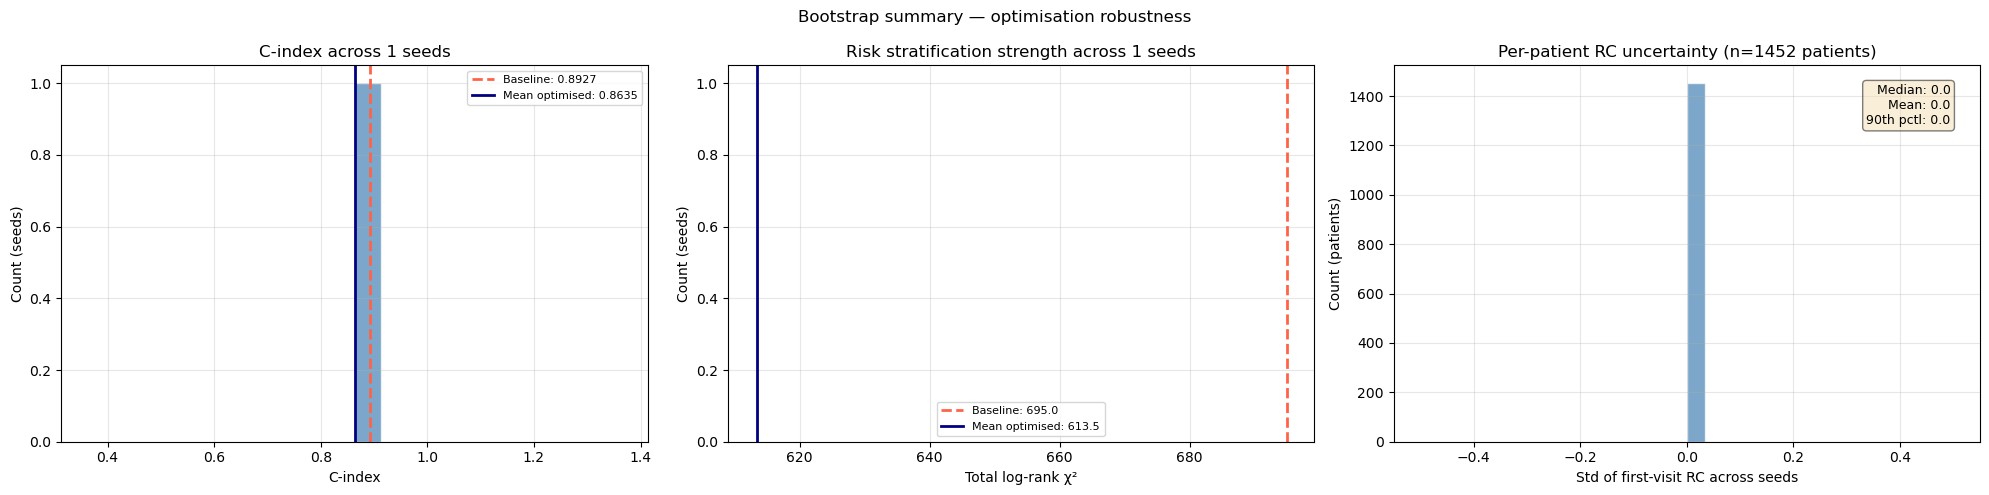


Bootstrap summary across 1 seeds:
  C-index: 0/1 seeds improved over baseline (0%)
  C-index range: [0.8635, 0.8635], mean improvement: +-0.0292
  Log-rank χ²: 0/1 seeds improved over baseline (0%)
  Per-patient RC std: median=0.0, mean=0.0


/tmp/ipykernel_2407117/785248872.py:395: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(box_data, labels=box_labels, patch_artist=True,
/tmp/ipykernel_2407117/785248872.py:411: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(box_data_cv, labels=box_labels, patch_artist=True,


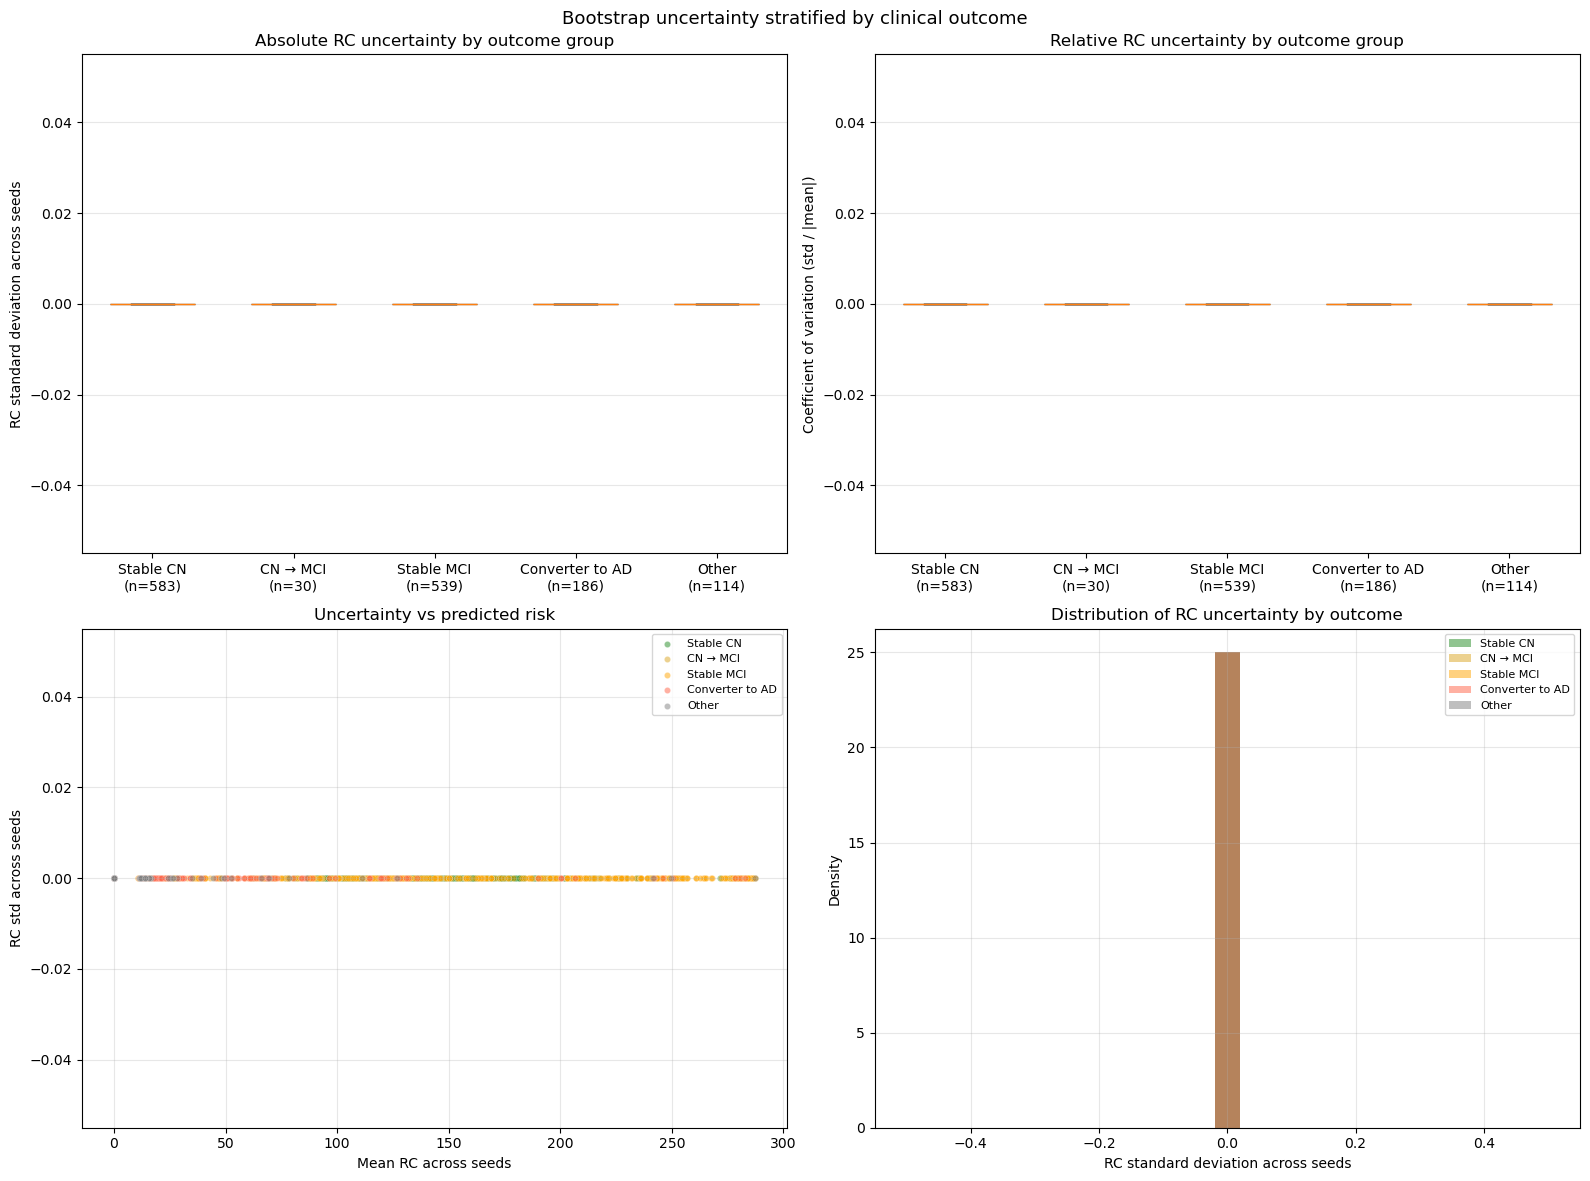


Category                 n    RC mean     RC std       CV   Std median   Std 90th
--------------------------------------------------------------------------------
Stable CN              583      136.4        0.0    0.000          0.0        0.0
CN → MCI                30      144.9        0.0    0.000          0.0        0.0
Stable MCI             539      146.5        0.0    0.000          0.0        0.0
Converter to AD        186       37.5        0.0    0.000          0.0        0.0
Other                  114       16.1        0.0    0.000          0.0        0.0


In [278]:
# ============================================================================
# STEP 11: PATIENT-LEVEL BOOTSTRAPPING
# ============================================================================
# This directly mirrors Krivov's plots_patient_bootstrap_id from the
# experimental-testing notebook. For individual patients, it overlays the
# RC trajectory from all 60 optimisation seeds, showing how confident the
# model is about that specific patient's disease progression.
#
# The left panel shows all 60 trajectories as semi-transparent lines with
# the best seed highlighted in bold. The right panel shows the mean RC
# trajectory with ±1 standard deviation and min-max range as shaded bands.
#
# HOW TO INTERPRET:
# A narrow band means all 60 seeds agree on this patient's risk trajectory
# — the optimisation is well-constrained for this individual. A wide band
# means the patient's position on the RC is ambiguous — the data doesn't
# strongly determine where they sit. This is clinically important: you can
# only make confident prognostic statements for patients with narrow bands.
#
# WHAT TO LOOK FOR:
# Patients who are clearly converting (CN → MCI → AD) should show narrow
# bands that decrease over time — all seeds agree they're progressing.
# Patients in the borderline MCI region might show wide bands, reflecting
# genuine clinical uncertainty about their trajectory. If the band is wide
# at early visits but narrows at later visits, it means additional follow-up
# data is reducing prognostic uncertainty, which validates the longitudinal
# approach.
# ============================================================================

# Show bootstrap bands for automatically-selected interesting patients
plot_bootstrap_multi_patients(results_model, df, n_patients=6,
                               trajectory_type='ad_converters',
                               highlight_best=best_idx)

# You can also examine specific patients by RID
# plot_patient_bootstrap(results_model, df, patient_id=4.0,
#                        highlight_best=best_idx)

# ============================================================================
# STEP 12: POPULATION-LEVEL BOOTSTRAP SUMMARY
# ============================================================================
# This shows three histograms summarising the robustness of the optimisation
# across all 60 seeds at the population level.
#
# Left panel: Distribution of C-indices across seeds, with the baseline
# marked as a red dashed line. If the entire histogram sits to the right of
# the baseline, every single seed improved the model — this is the strongest
# possible evidence against overfitting.
#
# Middle panel: Distribution of total log-rank chi-squared across seeds.
# This shows whether the improvement in survival curve separation is
# consistent. Some seeds may produce lower chi-squared than baseline even
# if their C-index improved, because the log-rank test is sensitive to how
# patients are binned into quartiles.
#
# Right panel: Per-patient RC standard deviation across seeds. Each patient
# gets a single number: the standard deviation of their first-visit RC
# across all 60 seeds. This histogram shows the overall uncertainty
# distribution. A long right tail means some patients have highly uncertain
# RC assignments — these are the patients you should be cautious about when
# making clinical claims.
#
# FOR YOUR REPORT:
# The key statistic to quote is "X out of 60 seeds (Y%) improved the
# C-index over baseline." If this is 60/60 (100%), that's a very strong
# result. The per-patient uncertainty panel contextualises the improvement
# by showing that while the overall ranking improves, individual patient
# scores carry meaningful uncertainty.
# ============================================================================
plot_bootstrap_summary_stats(results_model, df)

# ============================================================================
# STEP 13: BOOTSTRAP UNCERTAINTY STRATIFIED BY OUTCOME
# ============================================================================
# This breaks down the per-patient RC uncertainty from Step 12 by clinical
# outcome group, testing the hypothesis that the aggregate standard
# deviation of ~209 is driven primarily by stable CN patients rather than
# by patients the model actually needs to be accurate about.
#
# HOW TO INTERPRET:
# The top-left panel (box plot of absolute std) will likely show that
# AD converters have much tighter RC distributions across seeds than
# stable CN patients. This makes physical sense: converters sit near the
# AD boundary where the free energy landscape has a clear gradient — all
# seeds agree these patients are close to converting. Stable CN patients
# sit in the flat plateau region far from the boundary, where the
# landscape provides little information about their exact position.
# Different seeds can place a stable CN patient at MFPT = 600 or MFPT = 900
# without meaningfully affecting the model's predictions, because both
# values say the same thing clinically: "very far from AD."
#
# The top-right panel (coefficient of variation) normalises by the mean RC,
# which may tell a different story. Even though stable CN patients have
# higher absolute std, their CV might be comparable to converters because
# their mean RC is also much larger. If converters have LOW absolute std
# AND low CV, while CN patients have HIGH absolute std but moderate CV,
# it means the uncertainty is proportional to scale — which is reassuring.
#
# The bottom-left scatter (mean vs std) is the most revealing. If you see
# a clear fan shape — low std at low mean RC (converters), high std at
# high mean RC (stable CN) — it confirms that uncertainty scales with
# distance from the boundary. Any patients with LOW mean RC but HIGH std
# would be concerning, as those are patients near AD whose risk score is
# poorly constrained.
#
# FOR YOUR REPORT:
# The key conclusion to draw is that the optimisation is most confident
# exactly where clinical confidence matters most — for patients
# approaching AD. The high uncertainty for stable CN patients is not a
# weakness but a reflection of the data: the 60-month observation window
# simply doesn't contain enough information to precisely estimate whether
# a healthy patient is 10 years or 15 years from AD, and the model is
# honestly representing that limitation rather than fabricating false
# precision.
# ============================================================================
plot_bootstrap_uncertainty_by_outcome(results_model, df)